In [ ]:
#Parameters

Scenario = NotImplementedError
T_planet = None
M_planet = None
R_planet = None
G_planet = None
Z_planet = None
Age = None
Sep_p = None

folder_name = None
day = None

Delete_old = None

log_file = None

In [ ]:
# Cell 1: Import necessary libraries and set up paths
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib

from scipy import interpolate
from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.linalg import svd, solve, det
from scipy.signal import savgol_filter

from exocrires import info
from exocrires import plotMatrix
from exocrires.spectra_processor import Spectra_fitting  
from exocrires.spectra_processor import processor_cross_correlation
from exocrires.spectra_processor import processor_likelihood_map

from astropy.io import fits

import glob
import tqdm
import time 
import os 
import shutil
import gc

# Define paths to data directories
font = {'size': 20}
plt.rcParams.update({'font.size': font['size']})

model_name='%s-%s-%s'%(T_planet,G_planet,Z_planet)

band='K2166'
distance=140 #pc

#sep_AU=82.6 #AU
#sep=sep_AU/distance #arcsec
#po=int(np.ceil(sep/0.059))
po=Sep_p

path_a = '/Users/richard/project_EXOCRIRES/' + folder_name 
path_b = '/Users/richard/project_EXOCRIRES'
path_file=path_a+'/%s/planet/%s/%s'%(day, model_name, band)

simulation_log = pd.read_csv(path_b+'/%s'%log_file)

Mod=np.loadtxt(path_a+'/spectra_input/upload_lowres_K2166_rot_lsf.dat')
fMod = Mod[:,1] #flux
wMod = Mod[:,0] #wavelength in microns


fMod /= np.nanmax(fMod)

stack=np.load(path_file+'/ABBA_stack.npy') 
#series=np.load(path_file+'/ABBA_series.npy')

lambda_range=info.lambda_range

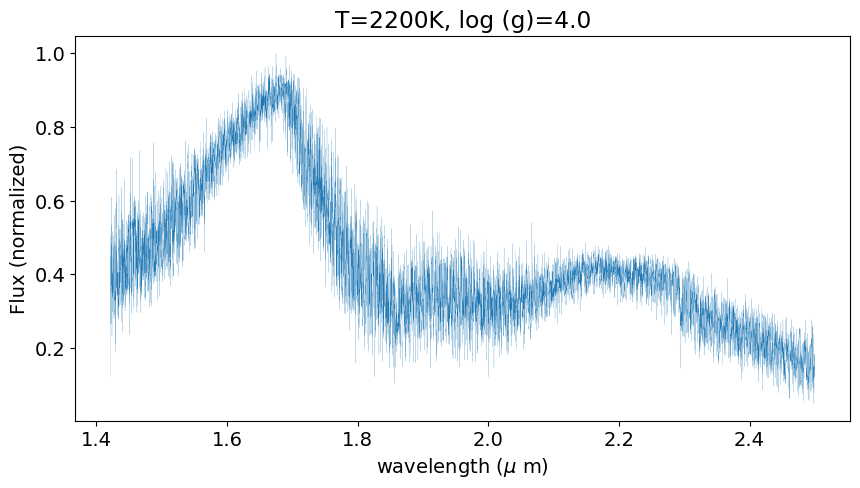

In [5]:
#Plot the normalized model spectrum
plt.rcParams.update({'font.size': 14})

fig = plt.figure(figsize=(10, 5))
plt.plot(wMod * 1e6, fMod, linewidth=0.1)  # Plot wavelength in micrometers
plt.xlabel('wavelength ($\\mu$ m)')
plt.ylabel('Flux (normalized)')

plt.title('T=%sK, log (g)=%s'%(model_name.split('-')[0], model_name.split('-')[1]))

# Uncomment to set x and y limits
# plt.xlim(1.0, 2.4)
# plt.ylim(0, 0.25)
plt.show()

## 0. Load the stacked mock observation and prepare the transmission cube

(7, 6144)
Folder not found: /Users/richard/project_EXOCRIRES/H2200_10_1.84_2.48/0308/star/K2166/ascii_1
Folder not found: /Users/richard/project_EXOCRIRES/H2200_10_1.84_2.48/0308/star/K2166/ascii_3
Folder not found: /Users/richard/project_EXOCRIRES/H2200_10_1.84_2.48/0308/star/K2166/ascii_5
Folder not found: /Users/richard/project_EXOCRIRES/H2200_10_1.84_2.48/0308/star/K2166/ascii_7
Folder not found: /Users/richard/project_EXOCRIRES/H2200_10_1.84_2.48/0308/star/K2166/ascii_9
Folder not found: /Users/richard/project_EXOCRIRES/H2200_10_1.84_2.48/0308/star/K2166/ascii_11
Folder not found: /Users/richard/project_EXOCRIRES/H2200_10_1.84_2.48/0308/star/K2166/ascii_13
Folder not found: /Users/richard/project_EXOCRIRES/H2200_10_1.84_2.48/0308/star/K2166/ascii_15
Folder not found: /Users/richard/project_EXOCRIRES/H2200_10_1.84_2.48/0308/star/K2166/ascii_17
Folder not found: /Users/richard/project_EXOCRIRES/H2200_10_1.84_2.48/0308/star/K2166/ascii_19
Folder not found: /Users/richard/project_EXOC

/var/folders/w_/fqznltwj2pz2y345p5_rzn3r0000gn/T/ipykernel_81876/7782999.py:22: RuntimeWarning: invalid value encountered in divide
  np.save(path_a+'/%s/sky/K2166/transmission_instrument.npy'%day, tot_transmission/atmos_transmission)


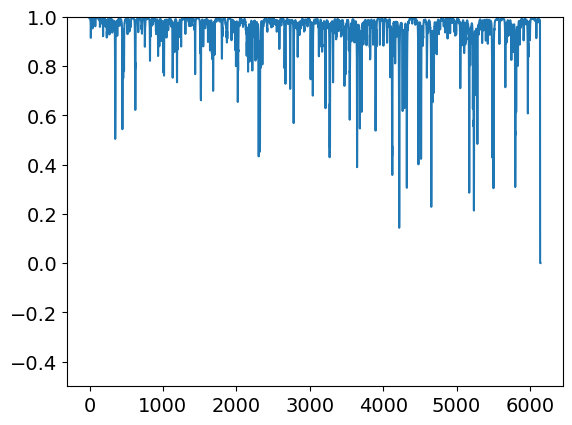

In [6]:
tot_transmission=np.zeros(shape=(stack.shape[0],stack.shape[2],2))
atmos_transmission=np.zeros(shape=(stack.shape[0],stack.shape[2],2))
sky_emission=np.zeros(shape=(stack.shape[0],stack.shape[2],2))
order=-3
for i in np.arange(29, 22, -1):

    index=0
    for j in range(1,4):
        #Do we use the total transmission or just the instrumental transmission ? What do we use in real observation ? 
        data_transmission=np.loadtxt(path_a+'/%s/star/K2166/ascii_35/converted_data_%s_throughput_totalinclsky_%s.txt'%(day, i,j),skiprows=1)
        data_atmos_transmission=np.loadtxt(path_a+'/%s/star/K2166/ascii_35/converted_data_%s_throughput_atmosphere_%s.txt'%(day, i,j),skiprows=1)
        emission=np.loadtxt(path_a+'/%s/star/K2166/ascii_35/converted_data_%s_signals_obssky_%s.txt'%(day, i,j),skiprows=1)
        
        tot_transmission[29-i][index*2046:(index+1)*2046]=data_transmission
        atmos_transmission[29-i][index*2046:(index+1)*2046]=data_atmos_transmission
        sky_emission[29-i][index*2046:(index+1)*2046]=emission

        index+=1
        
np.save(path_a+'/%s/sky/K2166/transmission.npy'%day, tot_transmission)
np.save(path_a+'/%s/sky/K2166/transmission_atmos.npy'%day, atmos_transmission)
np.save(path_a+'/%s/sky/K2166/transmission_instrument.npy'%day, tot_transmission/atmos_transmission)
np.save(path_a+'/%s/sky/K2166/sky_emission.npy'%day, sky_emission)

nDet=3 
nObs=35 
nPix=2048
nOrder=7
wlen = atmos_transmission[:,:,0]
print(wlen.shape)

plt.plot(atmos_transmission[order,:,1])
plt.ylim(-0.5,1)

#---ask user to delete the old files----


#Delete_old = input("Do you want to delete the old files? (yes/no): ").strip().lower()
if Delete_old == 'yes':
    for x in np.arange(1,35,2):

        folder_path = f"{path_a}/{day}/star/K2166/ascii_{x}"
        try:
            shutil.rmtree(folder_path)
            print(f"Deleted folder: {folder_path}")
        except FileNotFoundError:
            print(f"Folder not found: {folder_path}")
        except Exception as e:
            print(f"An error occurred: {e}")

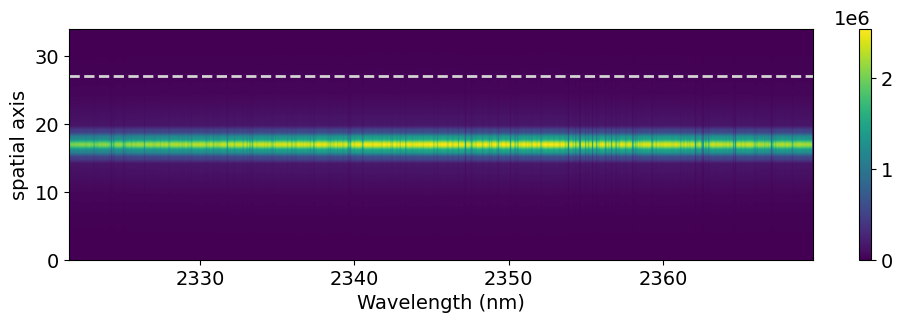

The planet position is at pixel 10


In [7]:

lambda_range=info.lambda_range

#for file in filenames[mask]:
    
order_window=lambda_range['wave'][3]

mask=np.array((wMod*1e3>=order_window[-2][0])&(wMod*1e3<=order_window[-2][1]))

#wMod=wMod[mask]
#fMod=fMod[mask]

plotMatrix.plotMatrix(stack[-3], order_window[-2], np.arange(0, 35, 1), 'Wavelength (nm)', 'spatial axis', planet_posi=(17+po), scale='linear')
plt.show()

print ('The planet position is at pixel %s'%po)


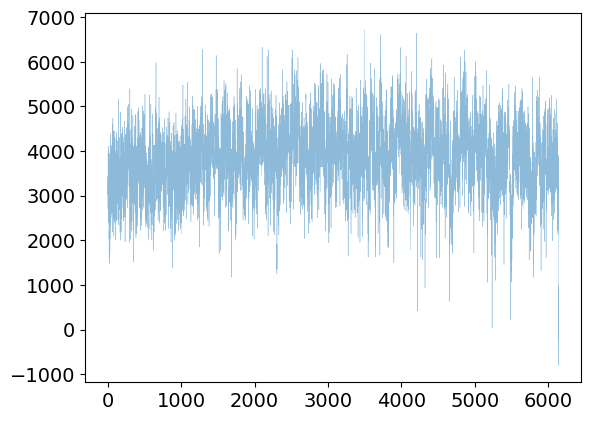

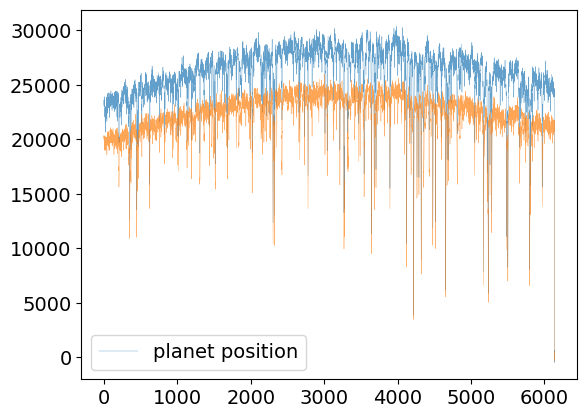

In [8]:
#first glimpse of the mock data to check the planet signal : F_planet - F_anti_planet
order=-3
plt.plot(stack[order][17+po,:]-stack[order][17-po,:],linewidth=0.3, alpha=0.5)

#k=np.nanmedian(stack[order][spatial_pix+10,:]-stack[order][spatial_pix-10,:])/np.nanmedian(fMod)

#plt.plot(fMod*k,linewidth=0.3, alpha=0.9, label='fMod')
#plt.plot(stack[order][spatial_pix-10,:],label='anti')

plt.show()

plt.plot(stack[order][17+po,:],linewidth=0.3, alpha=0.7, label='planet position')
plt.plot(stack[order][17-po,:],linewidth=0.3, alpha=0.7)
plt.legend()
plt.show()

## 1. Masking
Low Transmission Masking and bad-pixel masking

In [9]:
font = {'size': 20}
plt.rcParams.update({'font.size': font['size']})

band='K2166'
#path_file=path_a+'/%s/planet/%s/%s/noise_free'%(model_name,band)


transmission_instrument=np.load(path_a+'/%s/sky/K2166/transmission_instrument.npy'%day)
transmission_atmos=np.load(path_a+'/%s/sky/K2166/transmission_atmos.npy'%day)
sky_emission=np.load(path_a+'/%s/sky/K2166/sky_emission.npy'%day)
transmission_tot=np.load(path_a+'/%s/sky/K2166/transmission.npy'%day)

#mask the bad pixels and the low transmission ranges

atm_threshold=0.6
sigma_threshold=4

workflow_fitting=Spectra_fitting(stack, transmission_tot)


stack_sub_badpix=workflow_fitting.Mask_spec(transmission_atmos, atm_threshold, sigma_threshold)

np.save(path_file+'/stack_sub_badpix.npy', stack)

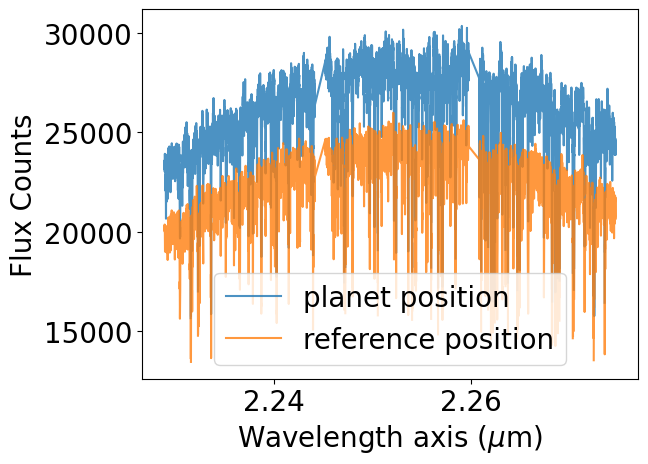

In [10]:
plt.plot(transmission_atmos[order,:,0][0:6138]*1e6, stack[order,17+po][0:6138],label='planet position', alpha=0.8)
plt.plot(transmission_atmos[order,:,0][0:6138]*1e6, stack[order,17-po][0:6138],label='reference position', alpha=0.8)

plt.xlabel('Wavelength axis ($\mu$m)')
plt.ylabel('Flux Counts')


plt.legend()
plt.show()

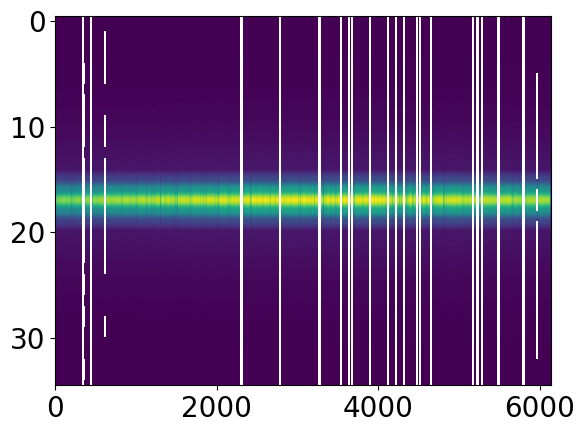

In [11]:
plt.imshow(stack_sub_badpix[-3], aspect='auto')
plt.show()

## 2.Starlight Subtraction

## Approach C: Fitting with a multiplicative factor
1. Extract the transmission profiles by dividing a PHOENIX model from the central pixel (assuming only the starlight and , as Landaman et al., 2023 excuted 
2. Correct the overall throughput with the extracted transmission profile ? --- We don't correct the overall throughput in the beginning. Instead we strictly follow Landman's approach. 
3. Inplement the low-pass ratio to normalize based on the continuum ratio between the observation and the model
4. Fit and subtract the starlight with a multiplicative factor

### 2.1 Extract the transmission profile and write in a matrix

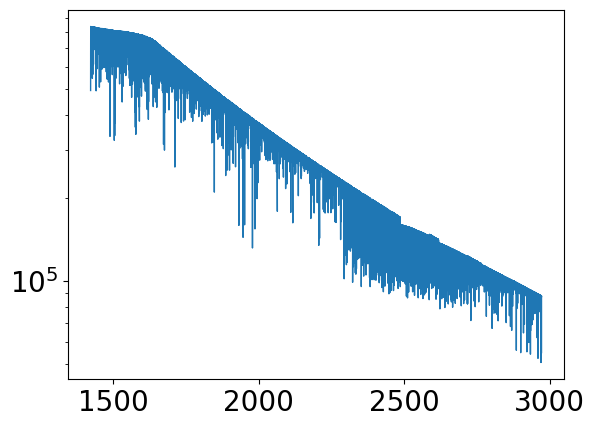

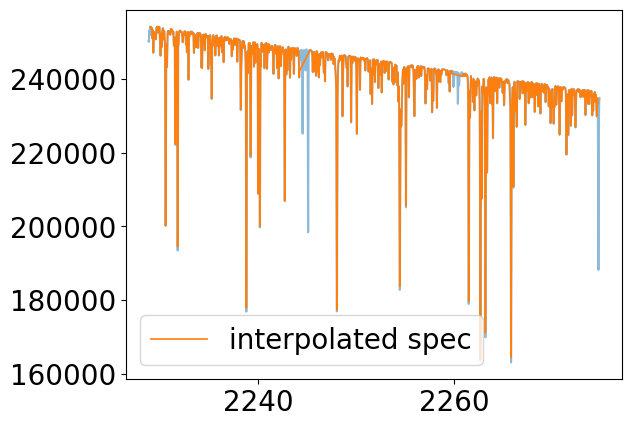

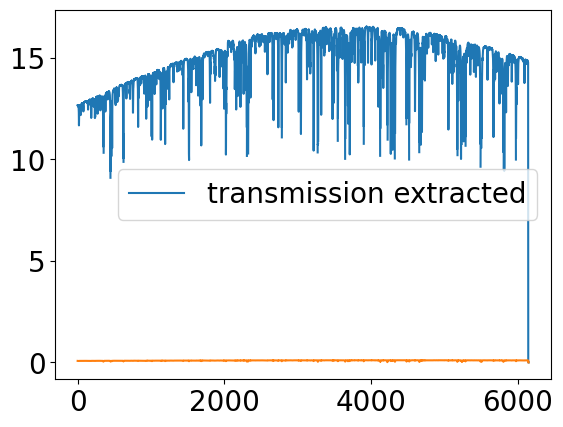

In [ ]:
#Extract the transmission profile

stack_sub_badpix=np.load(path_file+'/stack_sub_badpix.npy')
model_matrix_star=np.zeros(shape=(stack_sub_badpix.shape[0],stack_sub_badpix.shape[2]))

master_matrix=np.zeros(shape=(stack_sub_badpix.shape[0],stack_sub_badpix.shape[2]))
central_pix=17
spatial_pix=17+po
order=-3

#generate the master templates from bad_pixel removed spectra
for i in range(stack_sub_badpix.shape[0]):
    
    for x in range(3):
        
        master=stack_sub_badpix[i,central_pix][x*2046:(x+1)*2046]
        master_int=np.trapz(stack_sub_badpix[i, 16:19,x*2046:(x+1)*2046], axis=0)

        master_matrix[i, x*2046:(x+1)*2046]=master_int

#generate the model matrix of the star
phoenix_spec=np.loadtxt(path_a+'/spectra_input/upload_star_lowres_K2166_rot_lsf_10km.dat')
spec=phoenix_spec[:,1]
wave=phoenix_spec[:,0]

wave*=1e9

plt.plot(wave, spec, linewidth=1)
#plt.xlim(1e3, 4e3)
#plt.ylim(1e12, 1e15)
plt.yscale('log')
plt.show()

wave_range=lambda_range['wave'][3]

for i in range(stack_sub_badpix.shape[0]):

    mask=np.array((wave>=wave_range[i][0])&(wave<=wave_range[i][1]))

    spec_inter=np.interp(transmission_atmos[i,0:2046*3,0]*1e9, wave[mask], spec[mask])

    model_matrix_star[i][0:2046*3]=spec_inter


    
#division and normalization
transmission_matrix = np.zeros(shape=master_matrix.shape)

for i in range(master_matrix.shape[0]):
    
    trans = master_matrix[i,0:3*2046]/model_matrix_star[i, 0:3*2046]

    #trans /= np.nanmax(trans)

    transmission_matrix[i, 0:3*2046]=trans

mask=np.array((wave>=wave_range[order][0])&(wave<=wave_range[order][1]))

plt.plot(wave[mask], spec[mask], linewidth=1.5, alpha=0.5)
plt.plot(transmission_atmos[order, 0:2046*3, 0]*1e9, model_matrix_star[order][0:2046*3], linewidth=1.2, label='interpolated spec')
#plt.ylim(0.57e6, 0.59e6)
#plt.xlim(2255, 2265)

plt.legend()
plt.show()

plt.plot(transmission_matrix[order], label='transmission extracted')
plt.plot(tot_transmission[order,:,1])
#plt.ylim(8e5, 8.5e5)
#plt.xlim(0,2000)
plt.legend()
plt.show()

workflow_fitting.transmission_matrix=transmission_matrix

#### 2.1.1 Generate Planet Matrix

In [13]:

key_num=-3

for v in tqdm.tqdm(np.arange(-50,50,1)):
    
    data=np.loadtxt(path_a+'/spectra_input/upload_lowres_%s_rot_lsf_%skm.dat'%(info.lambda_range['key'][key_num],v))
    transmission=np.load(path_a+'/%s/sky/%s/transmission.npy'%(day, info.lambda_range['key'][key_num]))

    model_matrix=np.zeros(shape=(transmission.shape))

    for i in range(7):

        mask=np.array((data[:,0]>=np.min(transmission[i,:, 0][0:6138]))&(data[:,0]<=np.max(transmission[i,:, 0][0:6138])))
        spec_inter=np.interp(transmission[i,:, 0][0:6138], data[mask][:,0], data[mask][:,1])

        model_matrix[i,:, 0][0:6138]=transmission[i,:,0][0:6138]

        model_matrix[i,:, 1][0:6138]=spec_inter

    np.save(path_a+'/%s/planet/%s/%s/model_planet_matrix_%skm.npy'%(day, model_name, info.lambda_range['key'][key_num], v), model_matrix)

for v in tqdm.tqdm(np.arange(-50,50,1)):

    for mol in ['h2o_pokazatel', 'co', 'ch4']:
    
        data=np.loadtxt(path_a+'/spectra_input/upload_lowres_%s_rot_lsf_no_%s_%skm.dat'%(info.lambda_range['key'][key_num],mol, v))
        transmission=np.load(path_a+'/%s/sky/%s/transmission.npy'%(day, info.lambda_range['key'][key_num]))

        model_matrix=np.zeros(shape=(transmission.shape))

        for i in range(7):

            mask=np.array((data[:,0]>=np.min(transmission[i,:, 0][0:6138]))&(data[:,0]<=np.max(transmission[i,:, 0][0:6138])))
            spec_inter=np.interp(transmission[i,:, 0][0:6138], data[mask][:,0], data[mask][:,1])

            model_matrix[i,:, 0][0:6138]=transmission[i,:,0][0:6138]

            model_matrix[i,:, 1][0:6138]=spec_inter

        np.save(path_a+'/%s/planet/%s/%s/model_planet_matrix_%skm_no_%s.npy'%(day, model_name, info.lambda_range['key'][key_num], v, mol), model_matrix)

100%|██████████| 100/100 [00:15<00:00,  6.57it/s]


### 2.2 Fit the stellar contribution and the planet contribution

#### 2.2.1 Fit all contributions

In [77]:

stack=np.load(path_file+'/stack_sub_badpix.npy')
stack_planet_fit=np.zeros(shape=stack.shape)
model_matrix_planet=np.load(path_file+'/ABBA_stack.npy')
planet_model=np.load(path_file+'/model_planet_matrix_10km.npy')

window=300
polyorders=2

fit_matrix_planet, fit_matrix_star, fit_alpha_star, fit_alpha_planet, fit_model, popt_list=workflow_fitting.multiplicative_factor_fit(planet_model, order_list=np.arange(2, 7), window_len=window, Polyorder=polyorders)

[ 9.99876799e-01 -1.88178056e-04]
[ 1.00013947e+00 -3.37506874e-05]
[ 9.99878270e-01 -8.18898559e-05]
[1.00008676e+00 3.13130365e-04]
[9.99957049e-01 1.67861725e-06]
[ 1.00000585e+00 -7.23918685e-05]
[9.99997862e-01 7.98318631e-06]
[1.00003361e+00 3.51164871e-04]
[ 1.00004007e+00 -2.16432936e-04]
[9.99996882e-01 1.53989552e-04]
[9.99988722e-01 9.00502957e-05]
[ 1.00001188e+00 -2.66285468e-04]
[9.99992720e-01 2.32019268e-06]
[ 9.99997361e-01 -5.29973829e-04]
[ 1.00000651e+00 -1.36602528e-04]
[ 9.99994360e-01 -8.17808917e-06]
[ 9.99999591e-01 -8.09298860e-04]
[0.99999969 0.00100177]
[ 1.0000016  -0.00119422]
[9.99995458e-01 2.71227544e-04]
[9.99993294e-01 7.04948265e-05]
[1.00002291e+00 2.89140758e-04]
[ 9.99990072e-01 -1.80935703e-04]
[9.99967591e-01 2.69537745e-04]
[1.00001499e+00 4.64638764e-04]
[0.99995694 0.00155703]
[1.00005419 0.00298414]
[0.9999283  0.00650877]
[0.99986427 0.00357441]
[1.00002357 0.00168386]
[1.00004836e+00 5.08674037e-04]
[1.00002473e+00 5.77286981e-04]
[1.00003

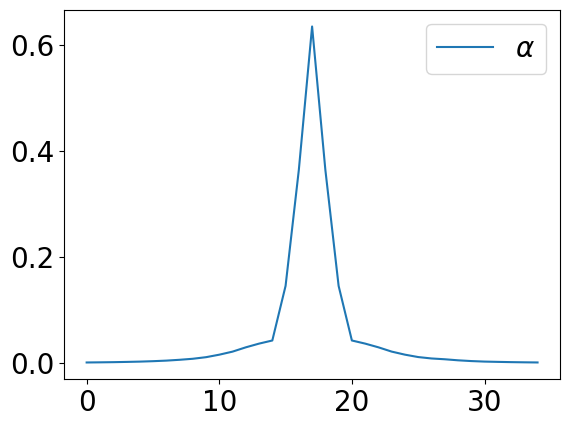

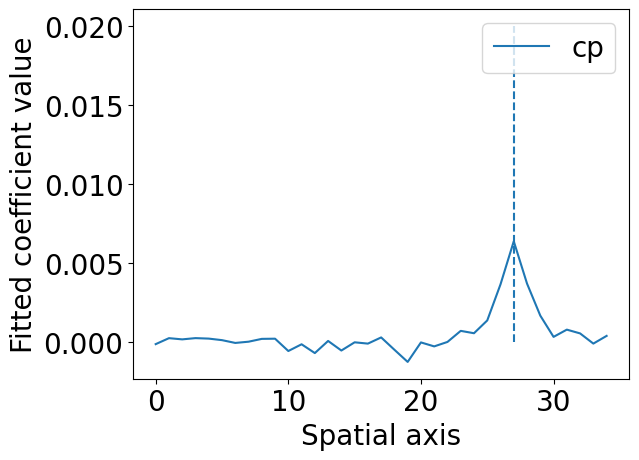

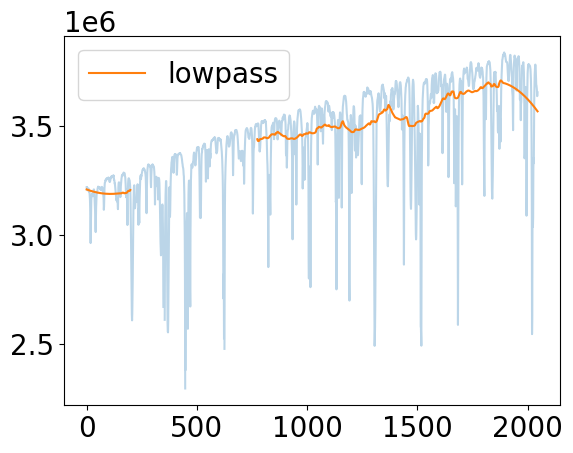

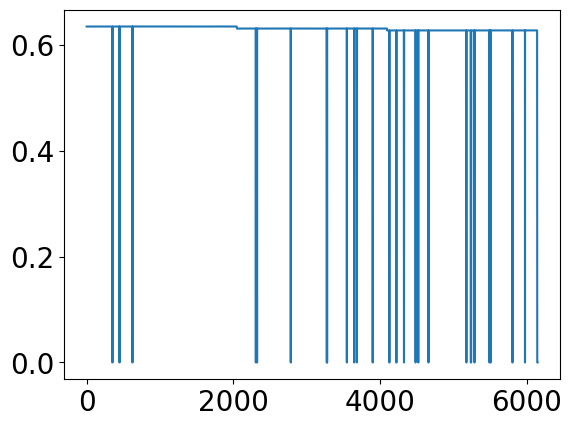

In [78]:
# run several tests to check the results
multi_factor=(fit_alpha_star[-3,:, 0:2046].T*popt_list[-3, :, 0, 0])

#plt.plot(multi_factor[1000],label=r'$c_s\alpha (\lambda)$')
plt.plot(fit_alpha_star[-3,:,1000], label=r'$\alpha$')
#plt.vlines(x=17, ymin=0, ymax=3e-2, ls='--')
#plt.vlines(x=27, ymin=0, ymax=3e-2, ls='--')
#plt.ylim(0.647,0.649)
#plt.xlim(1000,1010)
plt.legend()
plt.show()


plt.plot(popt_list[-3, :, 0, 1], label=['cp'])
#plt.hlines(y=1, xmin=0, xmax=35, ls='--', colors='gray')
plt.vlines(x=(17+po), ymin=0, ymax=0.02, ls='--')
plt.xlabel('Spatial axis')
plt.ylabel('Fitted coefficient value')
#plt.yscale('symlog')
plt.legend()
plt.show()

i=-3
x=0
master_int=np.trapz(stack_sub_badpix[i, 16:19,x*2046:(x+1)*2046], axis=0)
test_master=savgol_filter(master_int, window, polyorder=2)
plt.plot(master_int, alpha=0.3)
plt.plot(test_master, label='lowpass')

plt.legend()
plt.show()

plt.plot(fit_alpha_star[-3, 17])
#plt.ylim(0.64, 0.66)

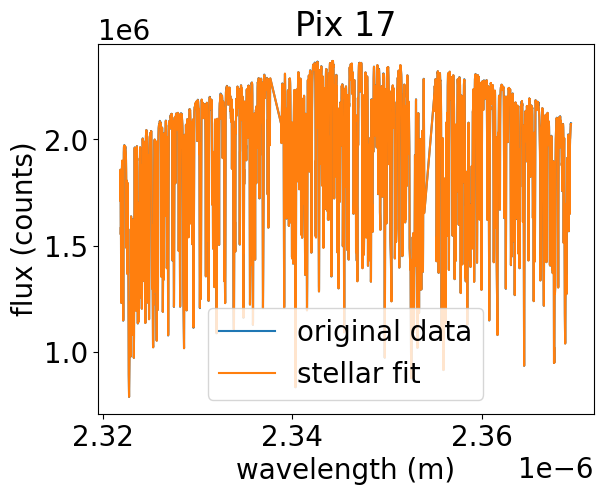

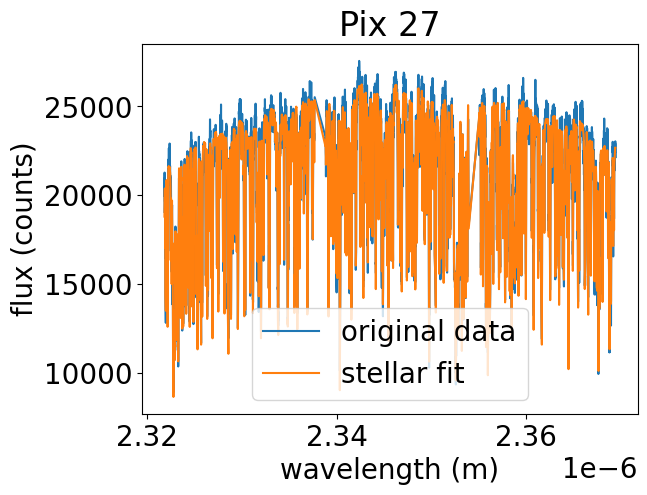

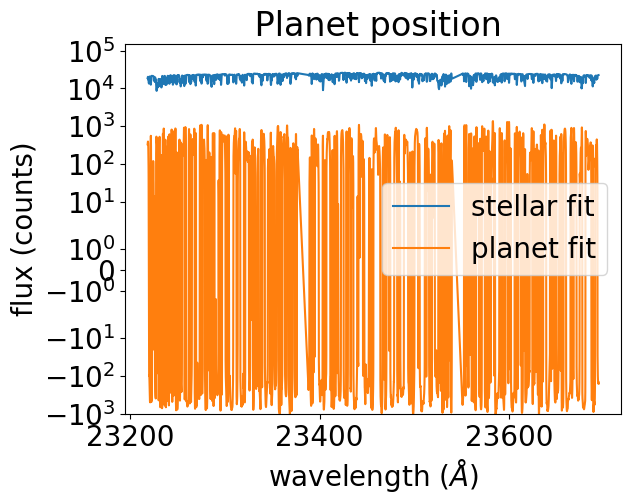

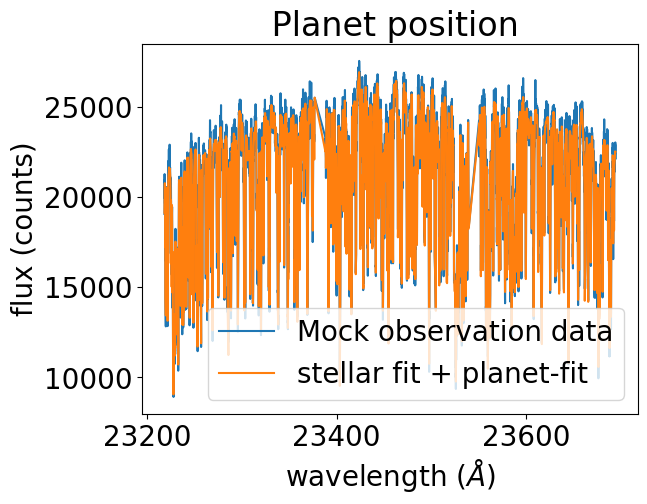

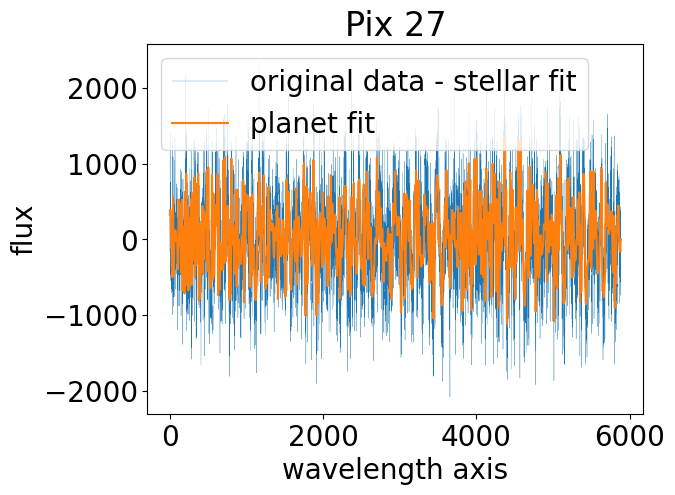

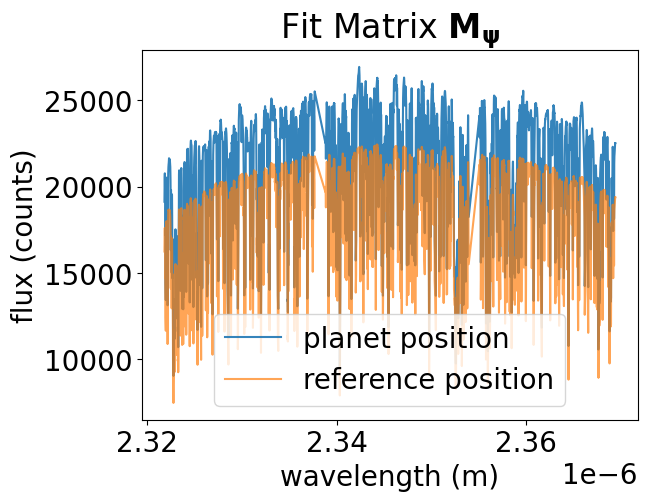

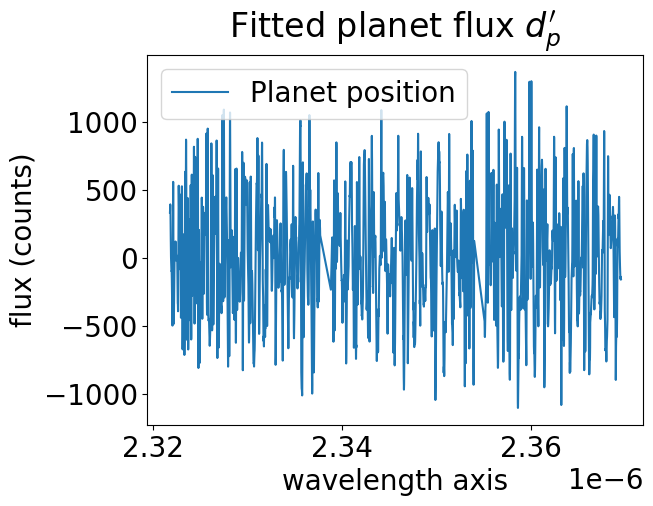

In [79]:
order=-2

mask_data = np.isfinite(stack[order,central_pix])
mask_wave = np.array(transmission_atmos[order,:,0]!=0)


plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data], stack[order,central_pix][mask_wave&mask_data], label='original data')
plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data], fit_matrix_star[order, central_pix][mask_wave&mask_data], label='stellar fit')

plt.xlabel('wavelength (m)')
plt.ylabel('flux (counts)')
plt.title('Pix %s'%central_pix)

plt.legend()
plt.show()

plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data], stack[order,spatial_pix][mask_wave&mask_data],label='original data')
plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data], fit_matrix_star[order,spatial_pix][mask_wave&mask_data], label='stellar fit')


plt.title('Pix %s'%spatial_pix)

plt.xlabel('wavelength (m)')
plt.ylabel('flux (counts)')

plt.legend()
plt.show()


fit_matrix=fit_matrix_star+fit_matrix_planet

mask_fit=np.array(fit_matrix==0.)

fit_matrix[mask_fit]=np.nan

np.save(path_file+'/fit_matrix.npy', fit_matrix)

#plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data]*1e10, stack[order,spatial_pix][mask_wave&mask_data],label='original data')
plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data]*1e10, fit_matrix_star[order,spatial_pix][mask_wave&mask_data], label='stellar fit')

#plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data]*1e10, fit_matrix_star[order,spatial_pix][mask_wave&mask_data], label='stellar fit')
plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data]*1e10, fit_matrix_planet[order,spatial_pix][mask_wave&mask_data], label='planet fit')

#plt.xlim(22500, 22520)
plt.ylim(-1e3, 1.5e5)

plt.title(' Planet position')

plt.xlabel('wavelength ($\AA$)')
plt.ylabel('flux (counts)')

plt.yscale('symlog')

plt.legend()
plt.show()



#plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data]*1e10, fit_matrix_star[order,spatial_pix][mask_wave&mask_data], label='stellar fit')
plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data]*1e10, stack[order,spatial_pix][mask_wave&mask_data], label='Mock observation data')
plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data]*1e10, fit_matrix[order,spatial_pix][mask_wave&mask_data], label='stellar fit + planet-fit')

#plt.xlim(22500, 22520)
#plt.ylim(-1e3, 1.5e5)

plt.title(' Planet position')

plt.xlabel('wavelength ($\AA$)')
plt.ylabel('flux (counts)')

#plt.yscale('symlog')

plt.legend()
plt.show()

subtract=stack-fit_matrix_star

plt.plot(subtract[order,spatial_pix][mask_data],label='original data - stellar fit', linewidth=0.2)
plt.plot(fit_matrix_planet[order, spatial_pix][mask_data],label='planet fit')

plt.title('Pix %s'%spatial_pix)

plt.xlabel('wavelength axis')
plt.ylabel('flux')

plt.legend()
plt.show()


#plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data], stack[order, spatial_pix][mask_wave&mask_data], label='mock observation at planet position')
plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data], fit_matrix[order, spatial_pix][mask_wave&mask_data], label='planet position', alpha=0.9)
plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data], fit_matrix[order, central_pix-po][mask_wave&mask_data], label='reference position', alpha=0.7)

plt.xlabel('wavelength (m)')
plt.ylabel('flux (counts)')

plt.title('Fit Matrix $\mathbf{M_\psi}$')

plt.legend()
plt.show()


plt.plot(transmission_atmos[order,:,0][mask_wave&mask_data], fit_matrix_planet[order, 17+po][mask_wave&mask_data], label='Planet position')
plt.xlabel('wavelength axis')
plt.ylabel('flux (counts)')
plt.title("Fitted planet flux $d_p\'$")
plt.legend()

plt.show()

/var/folders/w_/fqznltwj2pz2y345p5_rzn3r0000gn/T/ipykernel_81876/2530859412.py:6: RuntimeWarning: divide by zero encountered in divide
  plt.plot((stack[order,i]-fit_matrix_star[order,i])/fit_matrix_star[order, i], label='%s'%i, alpha=0.3)


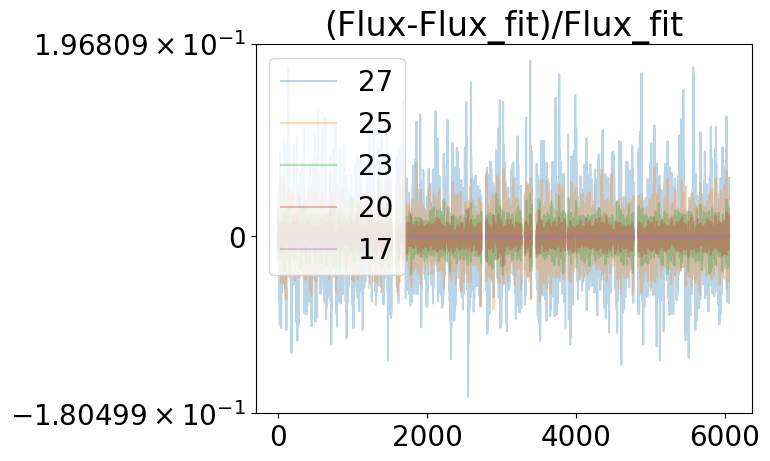

/var/folders/w_/fqznltwj2pz2y345p5_rzn3r0000gn/T/ipykernel_81876/2530859412.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


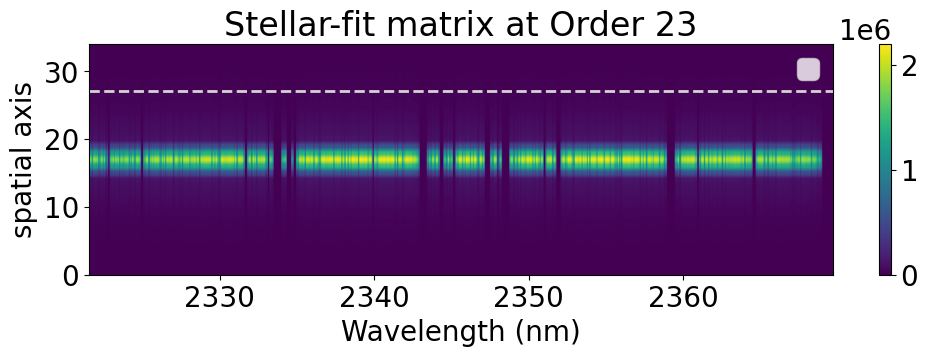

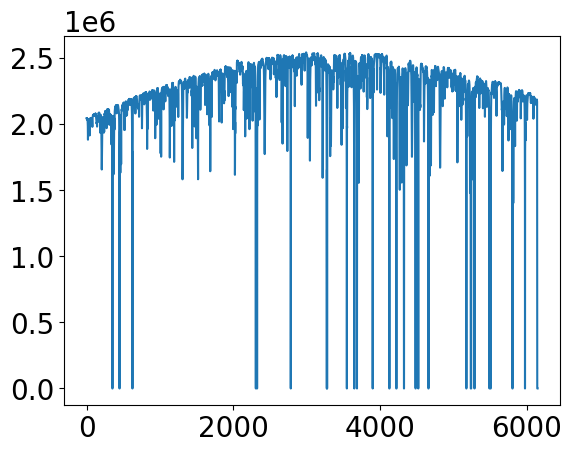

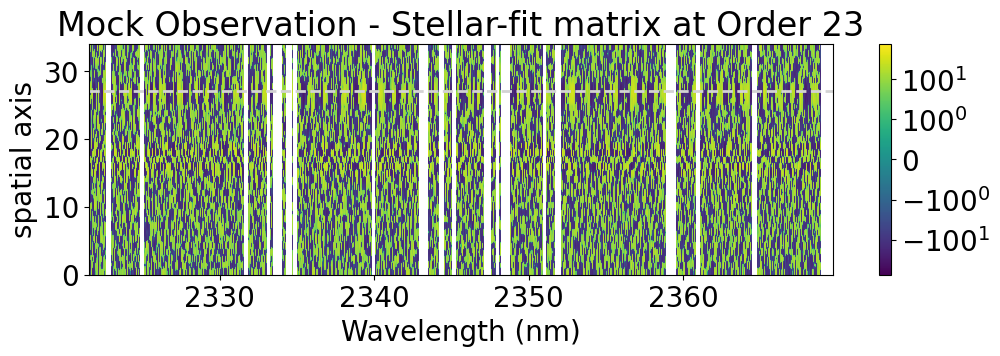

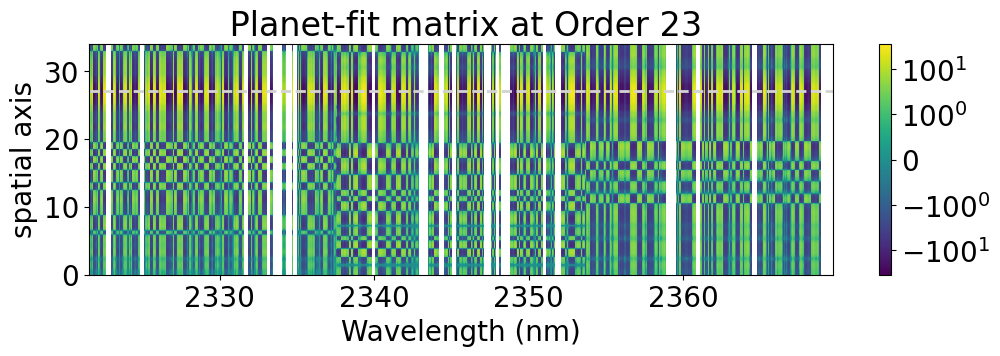

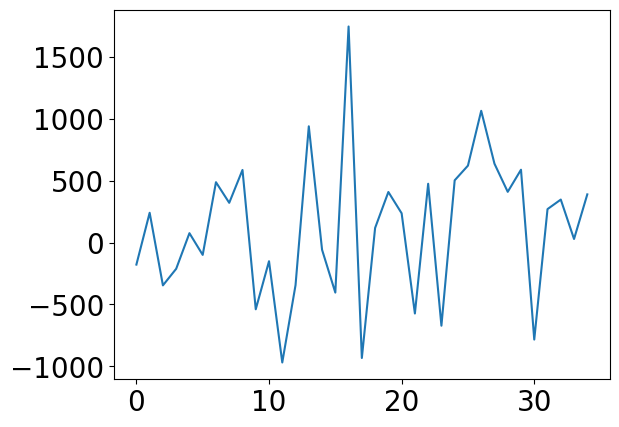

In [80]:
#plt.plot(stack[-1, 18, 2048*2:2048*3])
order=-1

for i in [17, 20, 23, 25, 27][::-1]:
    
    plt.plot((stack[order,i]-fit_matrix_star[order,i])/fit_matrix_star[order, i], label='%s'%i, alpha=0.3)
    #plt.plot((fit_martix[order, 27]-stack[order, 27])/stack[order, 27], label='27', alpha=0.3)
plt.yscale('symlog')
#plt.ylim(-1,1)
#plt.xlim(0, 500)
plt.title('(Flux-Flux_fit)/Flux_fit')
plt.legend()
plt.show()

plotMatrix.plotMatrix(fit_matrix_star[order], order_window[-2], np.arange(0, 35, 1), 'Wavelength (nm)', 'spatial axis', planet_posi=(17+po))
plt.title('Stellar-fit matrix at Order %s'%(22-order))
plt.legend()
plt.show()


plt.plot(fit_matrix_star[-3,17])
plt.show()

subtract=stack-fit_matrix_star
mask_sub=np.isfinite(subtract)
subtract[~mask_sub]=np.nan
fit_matrix_planet[~mask_sub]=np.nan

plotMatrix.plotMatrix(subtract[order], order_window[-2], np.arange(0, 35, 1), 'Wavelength (nm)', 'spatial axis', planet_posi=(17+po),scale='log')
plt.title('Mock Observation - Stellar-fit matrix at Order %s'%(22-order))
plt.savefig(path_file+'/mock_stellar.png', dpi=150)
plt.show()

plotMatrix.plotMatrix(fit_matrix_planet[order], order_window[-2], np.arange(0, 35, 1), 'Wavelength (nm)', 'spatial axis', planet_posi=(17+po), scale='log')
plt.title(' Planet-fit matrix at Order %s'%(22-order))


plt.savefig(path_file+'/fit_planet.png', dpi=150)
plt.show()

plt.plot(subtract[-3, :, 1600])
plt.show()


/var/folders/w_/fqznltwj2pz2y345p5_rzn3r0000gn/T/ipykernel_81876/3891383935.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(fit_matrix_star[order,:, i]/np.max(fit_matrix_star[order,:, i]))


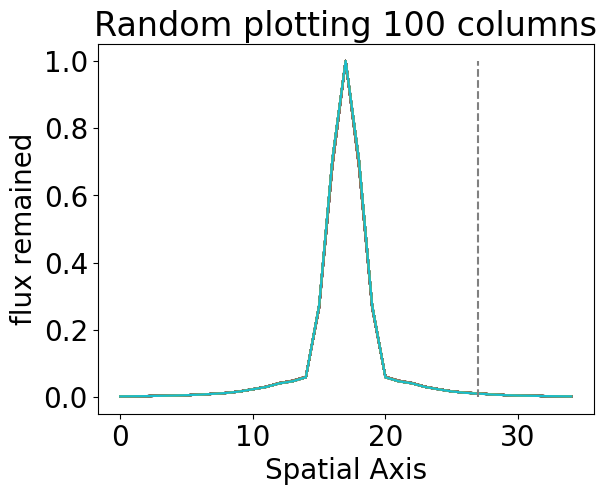

In [81]:
int_ran=np.random.randint(0, 6144, size=100)
for i in int_ran:
    plt.plot(fit_matrix_star[order,:, i]/np.max(fit_matrix_star[order,:, i]))

plt.xlabel('Spatial Axis')
plt.ylabel('flux remained')
plt.vlines(x=spatial_pix, ls='--', colors='Gray',ymin=0,ymax=1)
#plt.xlim(25,30)
#plt.ylim(-0.1,0.1)

plt.title('Random plotting 100 columns')
plt.show()

#### 2.2.2 Generate the model matrix using models with velocity (-50, 50) km/s

100%|██████████| 20/20 [00:46<00:00,  2.35s/it]


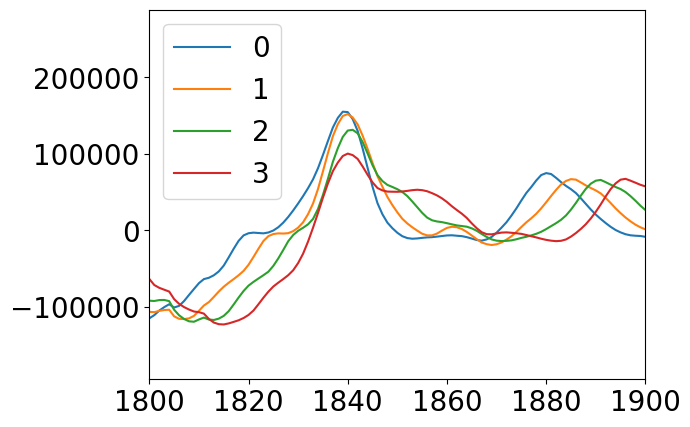

In [ ]:
vmin=-50
vmax=50
step=5
N_components=5 # Number of components to fit (0 for star, 1 for planet full spectrum, other 3 for planet without certain molecules)
grids_velocity=len(np.arange(vmin, vmax, step))

model_matrix_combine=np.zeros(shape=(grids_velocity, N_components, 7, 35, 6144))

window=300
c=1

n=0
for v in tqdm.tqdm(np.arange(vmin, vmax, step)):
    
    planet_model=np.load(path_file+'/model_planet_matrix_%skm.npy'%v)


    for i in range(2, stack_sub_badpix.shape[0]):
    
        for x in range(3):
            
            master=stack_sub_badpix[i,central_pix][x*2046:(x+1)*2046]
            master_int=np.trapz(stack_sub_badpix[i,16:19,x*2046:(x+1)*2046], axis=0)
            mask=np.isfinite(master_int)
    
            for j in range(stack_sub_badpix.shape[1]): 
    
                mask_data = np.isfinite(stack_sub_badpix[i,j][x*2046:(x+1)*2046])
                
                #------
                star_contribution = workflow_fitting.fit_star(c, master_int[mask&mask_data], observation=stack_sub_badpix[i, j, x*2046:(x+1)*2046][mask&mask_data], window_length=window, polyorder=2)
                planet_contribution = workflow_fitting.fit_planet(c, master_int[mask&mask_data], transmission_matrix[i,x*2046:(x+1)*2046][mask&mask_data], spec_planet=planet_model[i, x*2046:(x+1)*2046, 1][mask&mask_data], window_length=window, polyorder=2)
    
                model_matrix_combine[n][0][i,j][x*2046:(x+1)*2046][mask&mask_data]=star_contribution[1]
                model_matrix_combine[n][1][i,j][x*2046:(x+1)*2046][mask&mask_data]=planet_contribution[1]

    n+=1

    
    

n=0

for v in tqdm.tqdm(np.arange(vmin, vmax, step)):

    mol_index=2
    for mol in ['ch4', 'co', 'h2o_pokazatel']:
            
        planet_model=np.load(path_file+'/model_planet_matrix_%skm_no_%s.npy'%(v, mol))

        for i in range(2, stack_sub_badpix.shape[0]):

            for x in range(3):

                master=stack_sub_badpix[i,central_pix][x*2046:(x+1)*2046]
                master_int=np.trapz(stack_sub_badpix[i,16:19,x*2046:(x+1)*2046], axis=0)
                mask=np.isfinite(master_int)

                for j in range(stack_sub_badpix.shape[1]):

                    mask_data = np.isfinite(stack_sub_badpix[i,j][x*2046:(x+1)*2046])

                    #------
                    planet_contribution = workflow_fitting.fit_planet(c, master_int[mask&mask_data], transmission_matrix[i,x*2046:(x+1)*2046][mask&mask_data], spec_planet=planet_model[i, x*2046:(x+1)*2046, 1][mask&mask_data], window_length=window, polyorder=2)

                    model_matrix_combine[n][mol_index][i,j][x*2046:(x+1)*2046][mask&mask_data]=planet_contribution[1]

        mol_index+=1
            
    n+=1


#plotMatrix(model_matrix_combine[1][0][-3], order_window[-2], np.arange(0, 35, 1), 'Wavelength (nm)', 'spatial axis', planet_posi=(17+po))
plt.plot(model_matrix_combine[0][1][-3][27],label='0')
plt.plot(model_matrix_combine[1][1][-3][27],label='1')
plt.plot(model_matrix_combine[2][1][-3][27],label='2')
plt.plot(model_matrix_combine[3][1][-3][27],label='3')

plt.legend()
plt.xlim(1800,1900)
plt.show()

np.save(path_file+'/model_matrix_combine_%s_%s_%s_%s_%s.npy'%(vmin, vmax, step, N_components, window), model_matrix_combine)
print('Model matrix saved!')

## 3. Cross-correlation

### 3.2 Cross-correlation with templates for specific molecular species and full spectrum

We compare two different approaches for molecule detection: 1. molecule only templetes 2. Difference Map

#### 3.2.1 Monlecular-only templates

(47821,)
(47821,)
(47821,)
(47821,)


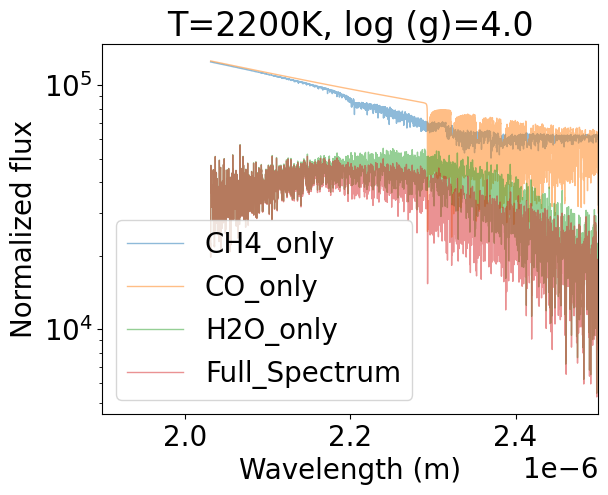

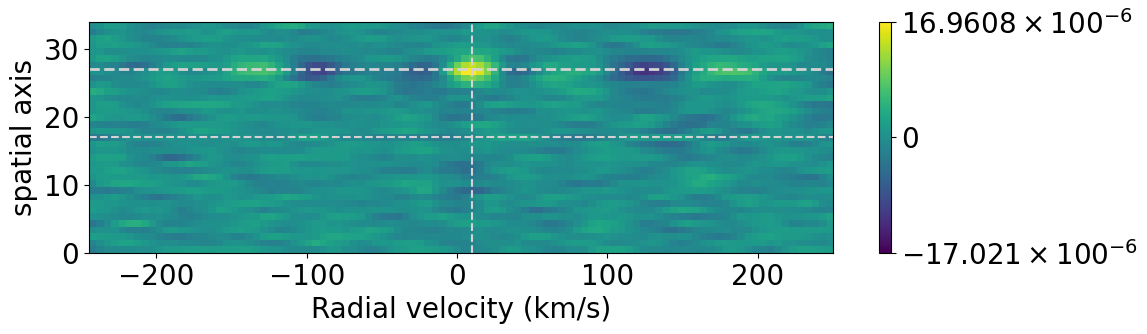

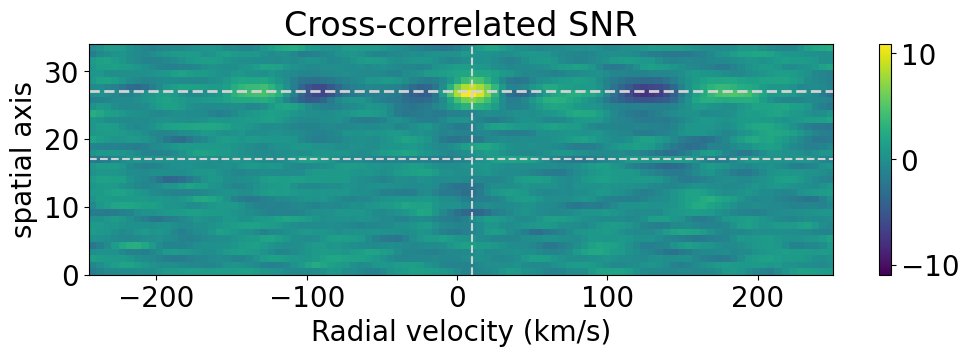

Cross correlation cube computed in  0.9 seconds


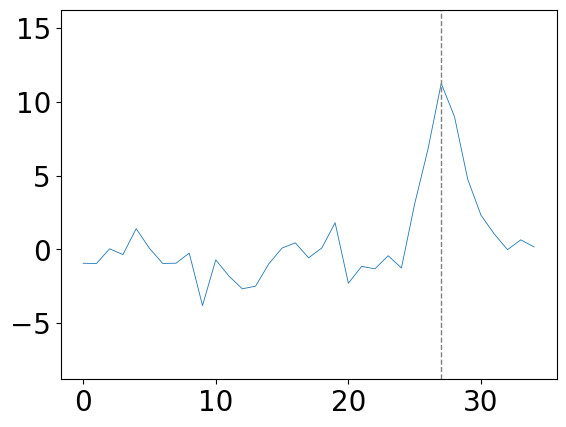

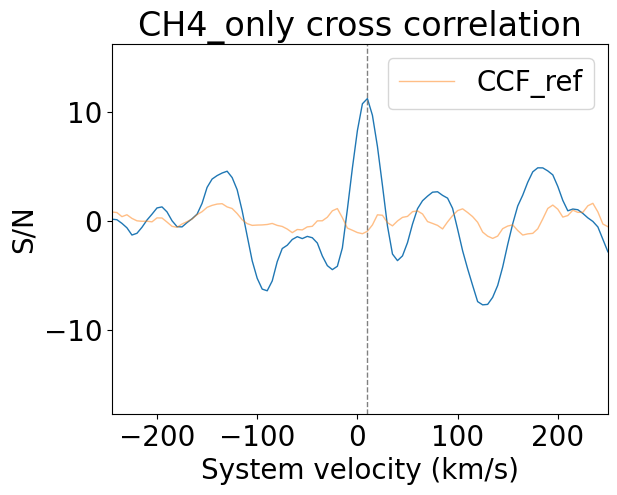

The maxium S/N is 11.254228854127257
The maxium S/N is at 10 km/s
The S/N at 10km/s is 11.254228854127257


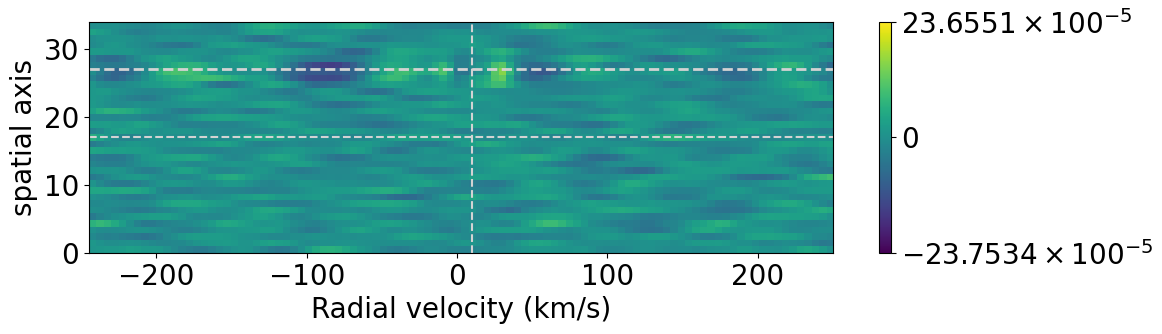

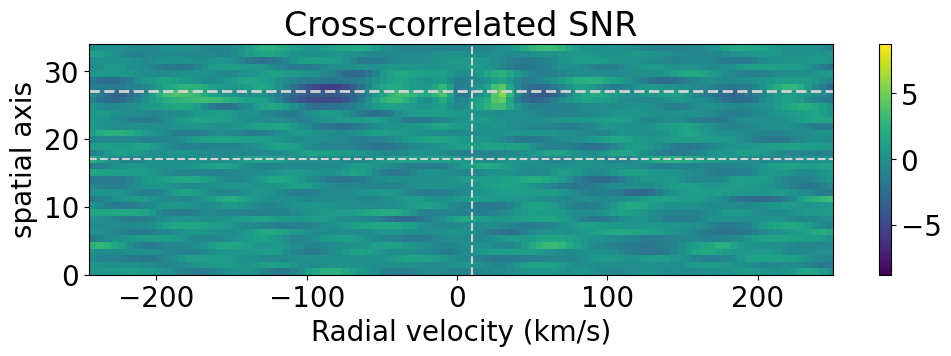

Cross correlation cube computed in  0.7 seconds


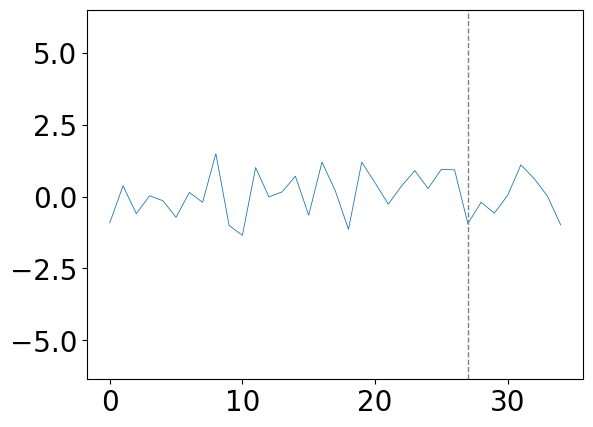

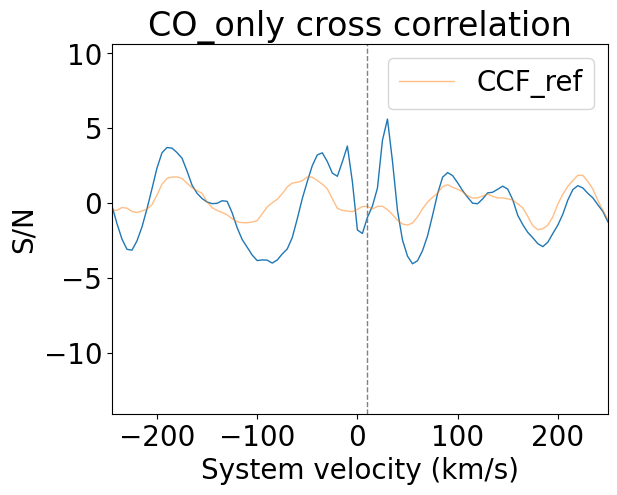

The maxium S/N is 5.612050670871058
The maxium S/N is at 30 km/s
The S/N at 10km/s is -0.9404105764147297


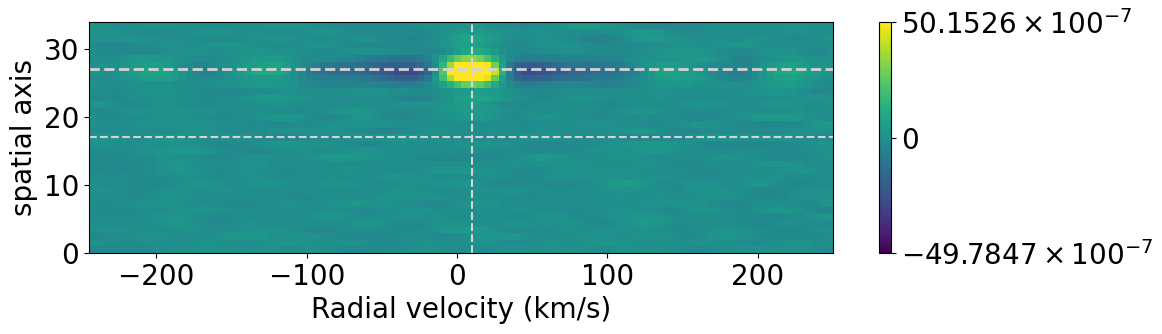

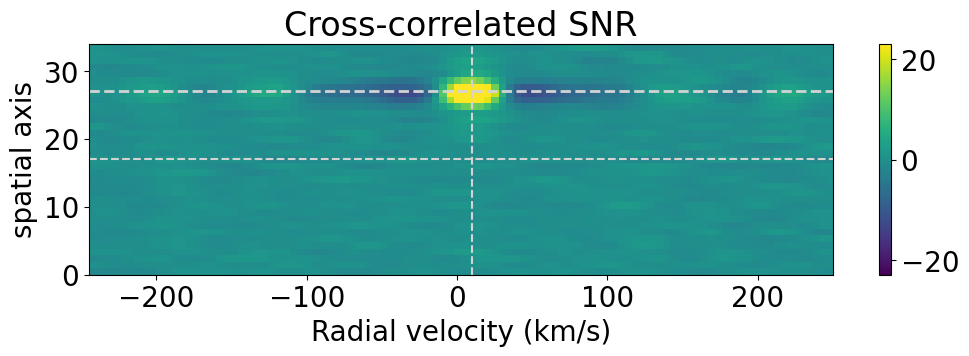

Cross correlation cube computed in  0.8 seconds


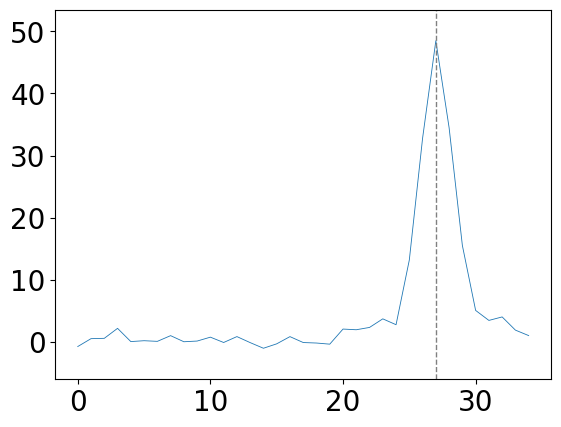

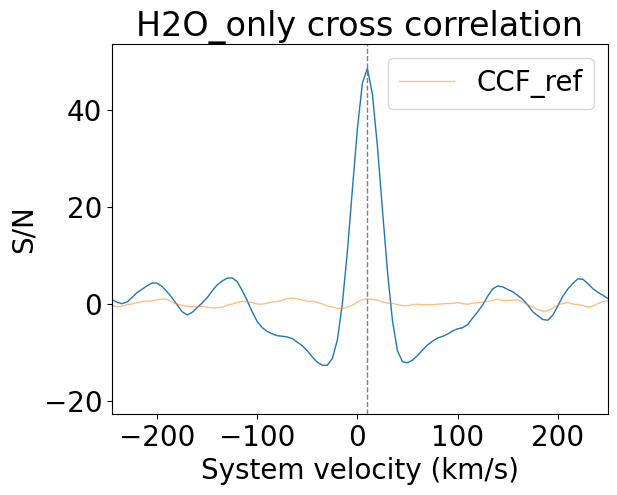

The maxium S/N is 48.507106534124915
The maxium S/N is at 10 km/s
The S/N at 10km/s is 48.507106534124915


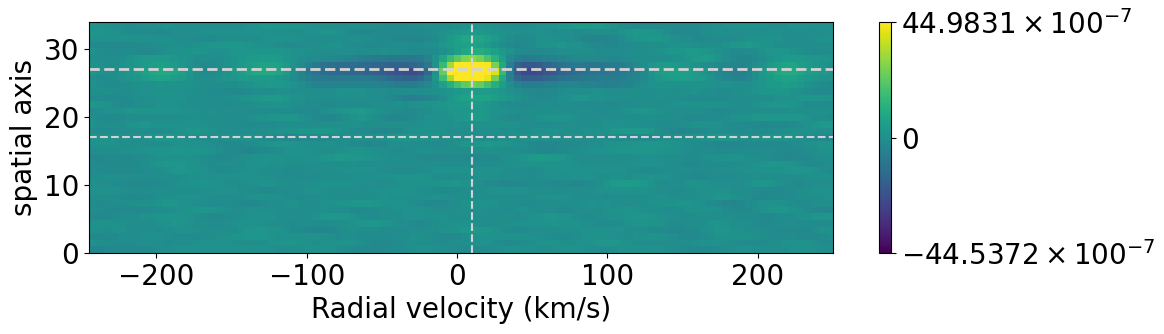

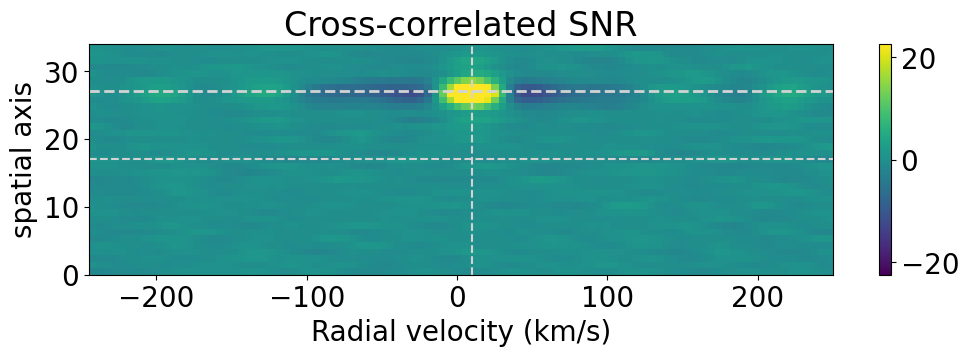

Cross correlation cube computed in  0.8 seconds


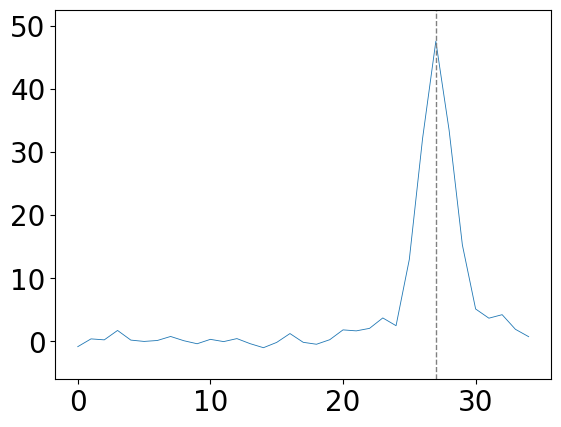

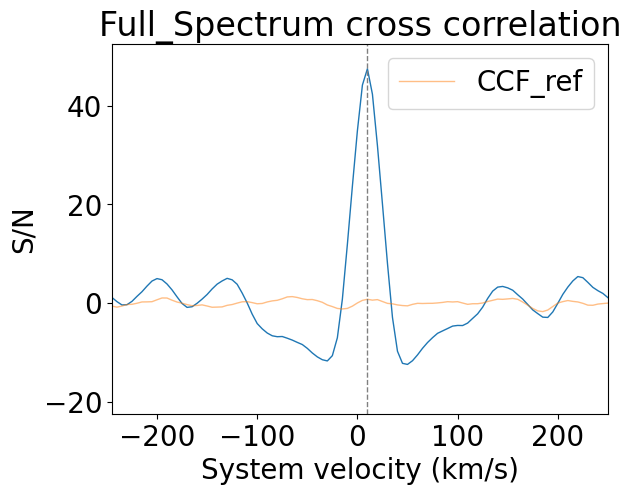

The maxium S/N is 47.52242049183036
The maxium S/N is at 10 km/s
The S/N at 10km/s is 47.52242049183036


In [ ]:
Mod_ch4=np.loadtxt(path_a+'/spectra_input/upload_lowres_K2166_rot_lsf_ch4_only.dat')
Mod_co=np.loadtxt(path_a+'/spectra_input/upload_lowres_K2166_rot_lsf_co_only.dat')
Mod_h2o=np.loadtxt(path_a+'/spectra_input/upload_lowres_K2166_rot_lsf_h2o_pokazatel_only.dat')
Mod=np.loadtxt(path_a+'/spectra_input/upload_lowres_K2166_rot_lsf.dat')
lambda_range=info.lambda_range  
mol_name=['CH4_only', 'CO_only', 'H2O_only', 'Full_Spectrum']

#clean up subtract spectra
mask_sub=np.isfinite(subtract)
mask=np.isfinite(fit_matrix_planet)
subtract[~mask_sub]=0.0
fit_matrix_planet[~mask]=0.0

subtract /= np.nanmax(subtract)  # Max-Normalize the flux

wMod= Mod[:, 0]  # Extract the wavelength values
fMod = Mod[:, 1]  # Extract the flux values

mask_wave=np.array(wMod*1e9>wave_range[1][1])

for x, mol in enumerate([Mod_ch4, Mod_co, Mod_h2o, Mod]):


    wMod_mo= mol[:, 0]  # Extract the wavelength values
    fMod_mo = mol[:, 1]  # Extract the flux values

    #Extract the continuum and normalize the model spectrum
    fMod_mo /= np.nanmax(fMod_mo)  # Max-Normalize the flux

    fMod_mo -= savgol_filter(fMod_mo, window_length=300, polyorder=2)

    fMod_mo -= np.nanmedian(fMod_mo)


    plt.plot(wMod_mo[mask_wave], fMod_mo[mask_wave], linewidth=1, label='%s'%mol_name[x], alpha=0.5)


    plt.xlim(2.33e-6, 2.34e-6)
    #plt.ylim(0,0.4)
    plt.yscale('linear')

    plt.xlabel('Wavelength (m)')
    plt.ylabel('Normalized flux')
    plt.title('T=%sK, log (g)=%s'%(model_name.split('-')[0], model_name.split('-')[1]))

    plt.legend(fontsize=20)

    print (wMod_mo[mask_wave].shape)



    #send warning if the wavlength shape is not conistent with each other
    if not (wMod_mo[mask_wave].shape == wMod[mask_wave].shape):
        print(f"Warning: Wavelength shape mismatch for {mol_name[x]}: {wMod_mo[mask_wave].shape} vs {wMod[mask_wave].shape}")






plt.show()




x=0
for mol in [Mod_ch4, Mod_co, Mod_h2o, Mod]:

    wMod_mo= mol[:, 0]  # Extract the wavelength values
    fMod_mo = mol[:, 1]  # Extract the flux values
    
    fMod_mo /= np.nanmax(fMod_mo)  # Normalize the flux

    fMod_mo -= savgol_filter(fMod_mo, window_length=300, polyorder=2)

    fMod_mo -= np.nanmedian(fMod_mo)

    mask_mo=np.array(wMod_mo*1e9>wave_range[1][1])


    t0 = time.time()

    #we only use the last two orders for the cross correlation with CO
    # and decrease the S/N
    #if x==1:  
    #workflow_cc=processor_cross_correlation(wMod_mo[mask_mo], fMod_mo[mask_mo], wlen[5:], cube=subtract[5:], nOrder=2, nObs=35)
    #else:
    workflow_cc=processor_cross_correlation(wMod_mo[mask_wave], fMod_mo[mask_wave], wlen[2:], cube=subtract[2:], nOrder=5, nObs=35)
    

    #----cross correlation----

    Ncc=500
    dRV=1.0
    RVlag=(np.arange(Ncc) - (Ncc-1)//2) * dRV
    ccf, ccf_snr=workflow_cc.ccf_tot(rvlag=RVlag , ncc=Ncc, clean_grids=[[0,10],[-10,-1]], central_pix=17, spatial_pix=(17+po), v_sys=10, subtract_continuum='False')

    print('Cross correlation cube computed in {:4.1f} seconds'.format(time.time()-t0))

    n=int(np.ceil((np.abs(RVlag.min())+10)/dRV))
    plt.plot(range(0,35,1), ccf_snr[:, n], linewidth=0.6)
    plt.vlines(x=spatial_pix, ymin=np.nanmin(ccf_snr[:, n])-5, ymax=np.nanmax(ccf_snr[:, n])+5, ls='--', linewidth=1, colors='Gray')

    plt.ylim(np.nanmin(ccf_snr[:, n])-5, np.nanmax(ccf_snr[:, n])+5)
    plt.show()

    plt.plot(RVlag, ccf_snr[spatial_pix], linewidth=1)
    plt.plot(RVlag, ccf_snr[17-po], linewidth=1, alpha=0.5, label='CCF_ref')

    plt.ylim(np.nanmin(ccf_snr[spatial_pix]-10), np.nanmax(ccf_snr[spatial_pix])+5)
    plt.xlim(RVlag.min(), RVlag.max())
    plt.vlines(x=10, ymin=np.nanmin(ccf_snr[spatial_pix])-10, ymax=np.nanmax(ccf_snr[spatial_pix])+5, ls='--', linewidth=1, colors='Gray')

    plt.ylabel('S/N')
    plt.xlabel('System velocity (km/s)')

    plt.title('%s cross correlation'%mol_name[x])

    plt.legend()

    plt.savefig(path_file+'/ccf_%s.png'%mol_name[x], dpi=150)
    plt.show()

    print ('The maxium S/N is %s'%np.nanmax(ccf_snr[spatial_pix]))
    print ('The maxium S/N is at %s km/s'%RVlag[np.nanargmax(ccf_snr[spatial_pix])])
    print ('The S/N at 10km/s is %s'%ccf_snr[spatial_pix][np.abs(RVlag-10).argmin()])

    

    # Save the cross-correlation results at 10km/s for each molecule
    ind=np.abs(RVlag-10).argmin()
    snr=ccf_snr[spatial_pix][ind]
    simulation_log.loc[simulation_log['Age']==Age, f'CCF_{mol_name[x]}'] = snr

    x+=1

#### 3.2.2 Difference Maps

(47821,)
(47821,)
(47821,)
(47821,)


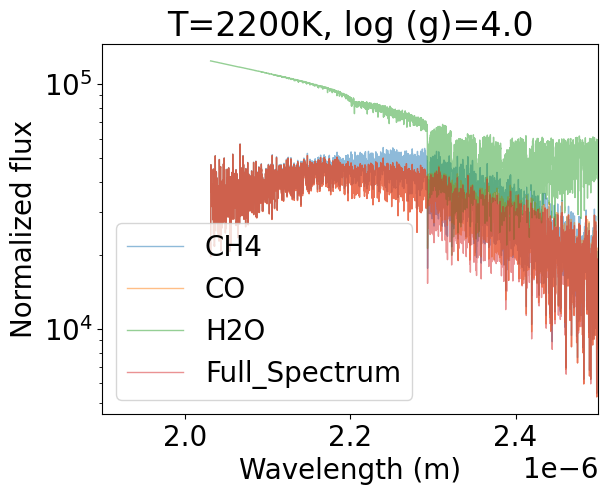

------- cross correlation with the full spectrum -------


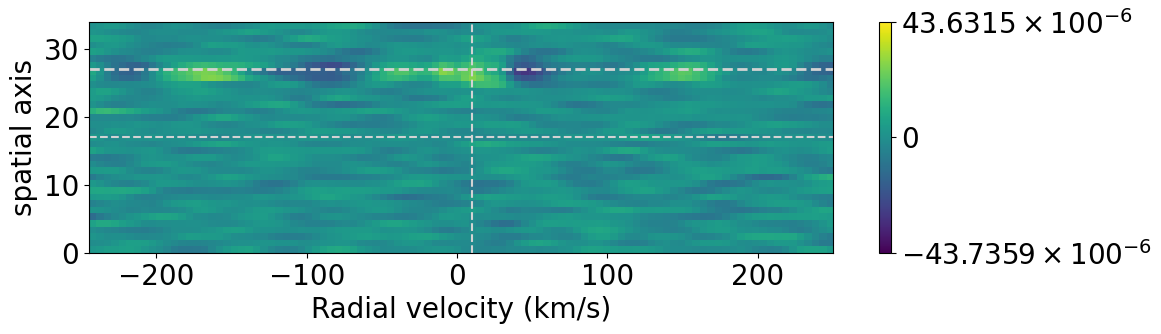

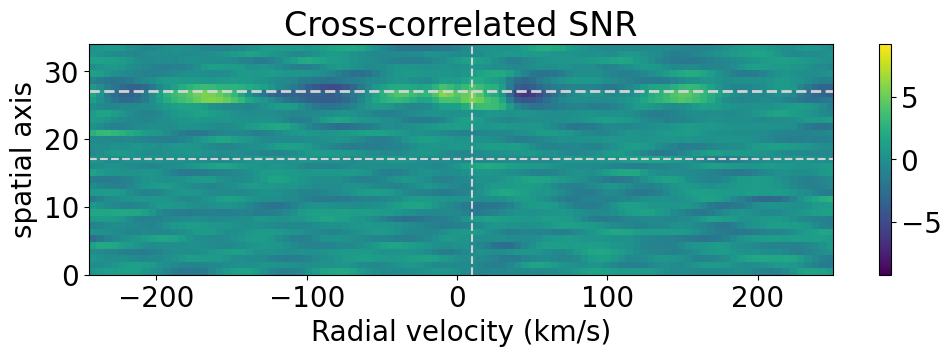

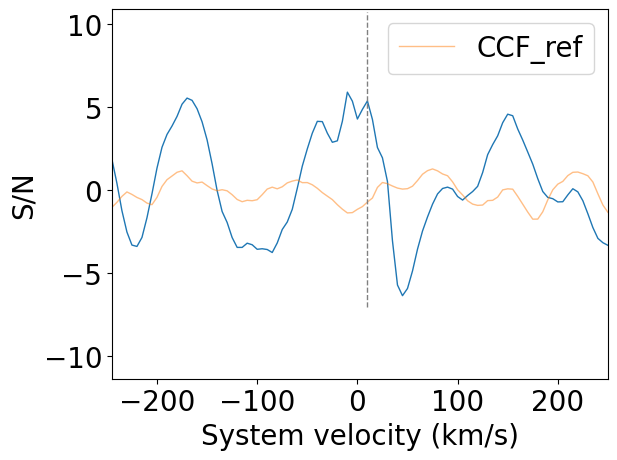

The maxium S/N is 5.878558801269635
The maxium S/N is at -10 km/s
The S/N at 10km/s is 5.3494128090002375
-----------------------------------------


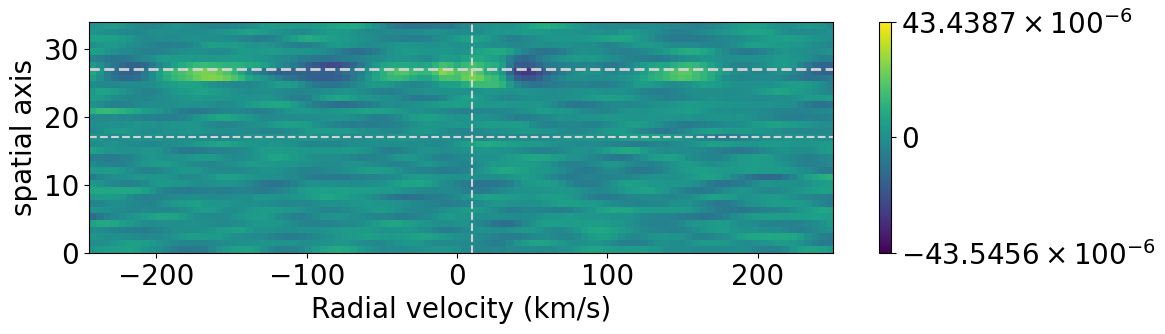

Cross correlation cube computed in  0.7 seconds


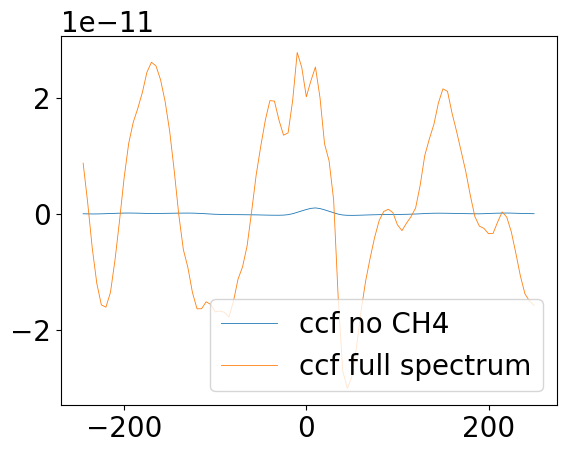

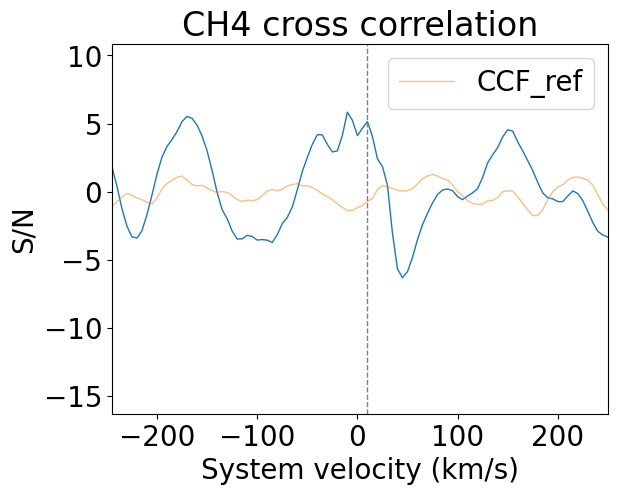

The maxium S/N is 5.8332617981235
The maxium S/N is at -10 km/s
The S/N at 10km/s is 5.143098028624726
-----------------------------------------


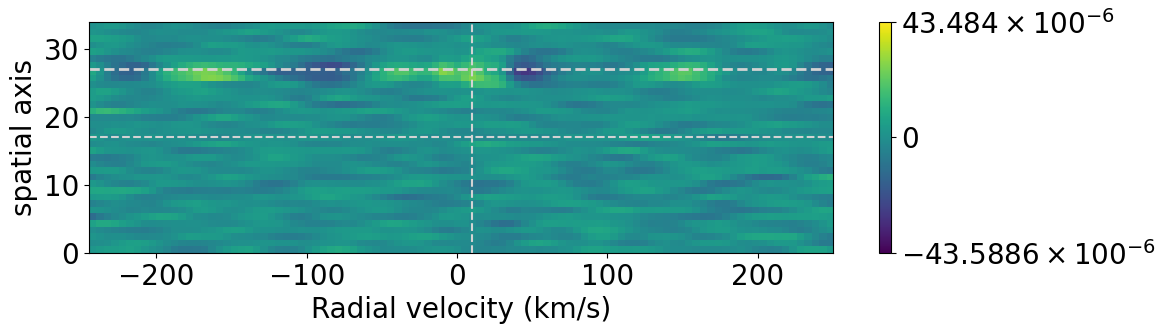

Cross correlation cube computed in  0.7 seconds


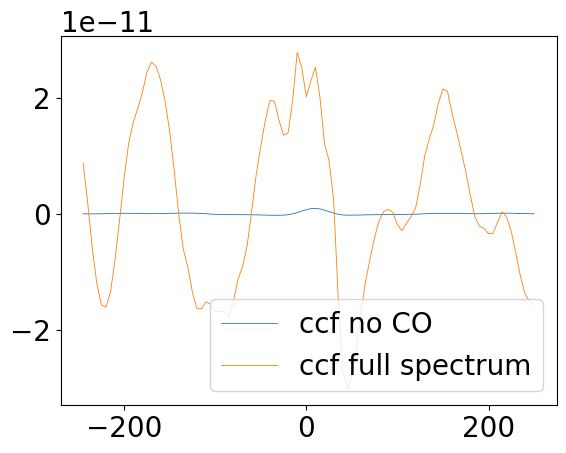

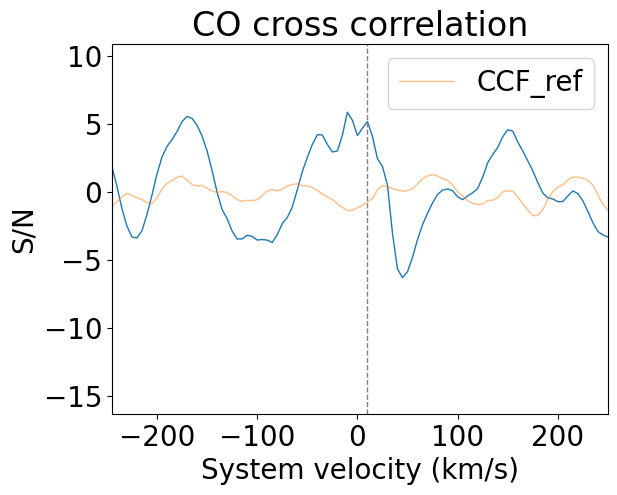

The maxium S/N is 5.839522907180748
The maxium S/N is at -10 km/s
The S/N at 10km/s is 5.154146407528018
-----------------------------------------


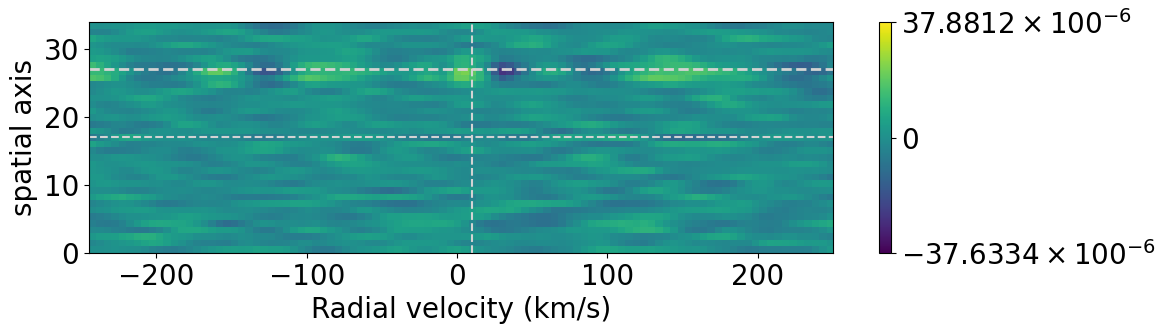

Cross correlation cube computed in  0.7 seconds


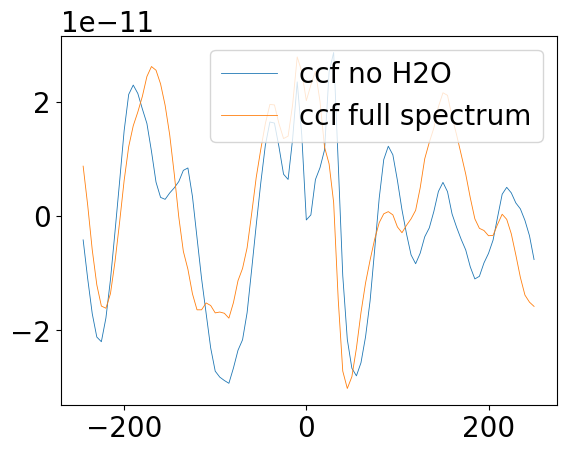

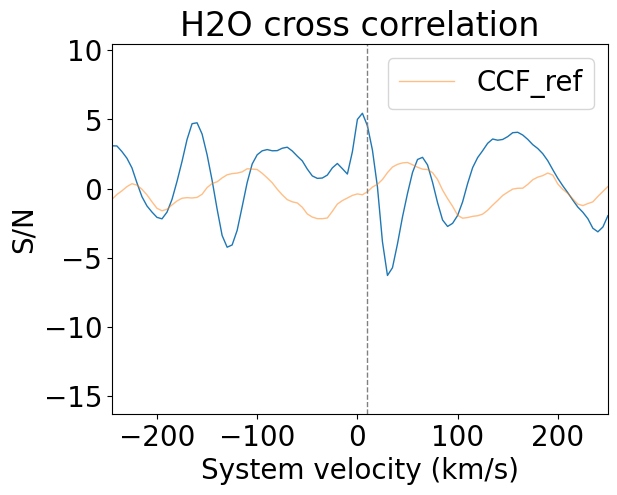

The maxium S/N is 5.445957546512975
The maxium S/N is at 5 km/s
The S/N at 10km/s is 4.541037406553227
-----------------------------------------


98446

In [ ]:
Mod_ch4=np.loadtxt(path_a+'/spectra_input/upload_lowres_K2166_rot_lsf_no_ch4.dat')
Mod_co=np.loadtxt(path_a+'/spectra_input/upload_lowres_K2166_rot_lsf_no_co.dat')
Mod_h2o=np.loadtxt(path_a+'/spectra_input/upload_lowres_K2166_rot_lsf_no_h2o_pokazatel.dat')
Mod=np.loadtxt(path_a+'/spectra_input/upload_lowres_K2166_rot_lsf.dat')
lambda_range=info.lambda_range  
mol_name=['CH4', 'CO', 'H2O', 'Full_Spectrum']

wMod= Mod[:, 0]  # Extract the wavelength values
fMod = Mod[:, 1]  # Extract the flux values


for x, mol in enumerate([Mod_ch4, Mod_co, Mod_h2o, Mod]):


    wMod_mo= mol[:, 0]  # Extract the wavelength values
    fMod_mo = mol[:, 1]  # Extract the flux values

    #fMod_mo -= savgol_filter(fMod_mo, window_length=300, polyorder=2)
    fMod_mo -= savgol_filter(fMod_mo, window_length=300, polyorder=2)
    fMod_mo -= np.nanmedian(fMod_mo)

    plt.plot(wMod_mo[mask_wave], fMod_mo[mask_wave], linewidth=1, label='%s'%mol_name[x], alpha=0.5)


    plt.xlim(2.349e-6, 2.35e-6)
    #plt.ylim(0,0.4)
    plt.yscale('linear')

    plt.xlabel('Wavelength (m)')
    plt.ylabel('Normalized flux')
    plt.title('T=%sK, log (g)=%s'%(model_name.split('-')[0], model_name.split('-')[1]))

    plt.legend(fontsize=20)

    print (wMod_mo[mask_wave].shape)

    #send warning if the wavlength shape is not conistent with each other
    if not (wMod_mo[mask_wave].shape == wMod[mask_wave].shape):
        print(f"Warning: Wavelength shape mismatch for {mol_name[x]}: {wMod_mo[mask_wave].shape} vs {wMod[mask_wave].shape}")




plt.show()

##-------cross correlation for the full spectrum---------------------------------------------------------------------------
wMod= Mod[:, 0]  # Extract the wavelength values
fMod= Mod[:, 1]  # Extract the flux values
fMod /= np.nanmax(fMod)  # Normalize the flux
fMod -= savgol_filter(fMod, window_length=300, polyorder=2)
fMod -= np.nanmedian(fMod)


#----cross correlation----

print ("------- cross correlation with the full spectrum -------")

#extract the continuum with low-pass filters
#fMod -= savgol_filter(fMod, window_length=300, polyorder=2)
mask_full=np.array(wMod*1e9>wave_range[1][1])
workflow_cc_full=processor_cross_correlation(wMod[mask_full], fMod[mask_full], wlen[2:], cube=subtract[2:], nOrder=5, nObs=35)

Ncc=500
dRV=1.0
RVlag=(np.arange(Ncc) - (Ncc-1)//2) * dRV
ccf_full, ccf_snr_full=workflow_cc.ccf_tot(rvlag=RVlag , ncc=Ncc, clean_grids=[[0,10],[-10,-1]], central_pix=17, spatial_pix=(17+po), v_sys=10,\
                                            subtract_continuum='False', plot=True)


plt.plot(RVlag, ccf_snr_full[spatial_pix], linewidth=1)
plt.plot(RVlag, ccf_snr_full[17-po], linewidth=1, alpha=0.5, label='CCF_ref')

plt.ylim(np.nanmin(ccf_snr_full[spatial_pix])-5,np.nanmax(ccf_snr_full[spatial_pix]+5))
plt.xlim(RVlag.min(),RVlag.max())
plt.vlines(x=10, ymin=np.nanmin(ccf_snr_full[spatial_pix]-5), ymax=np.nanmax(ccf_snr_full[spatial_pix]+5), ls='--', linewidth=1, colors='Gray')

plt.ylabel('S/N')
plt.xlabel('System velocity (km/s)')

plt.legend()

plt.show()

print ('The maxium S/N is %s'%np.nanmax(ccf_snr_full[spatial_pix]))
print ('The maxium S/N is at %s km/s'%RVlag[np.nanargmax(ccf_snr_full[spatial_pix])])
print ('The S/N at 10km/s is %s'%ccf_snr_full[spatial_pix][np.abs(RVlag-10).argmin()])



print('-----------------------------------------')
##-------cross correlation for certain molecules---------------------------------------------------------------------------
x=0
for mol in [Mod_ch4, Mod_co, Mod_h2o]:

    wMod_mo= mol[:, 0]  # Extract the wavelength values
    fMod_mo = mol[:, 1]  # Extract the flux values
    
    fMod_mo /= np.nanmax(fMod_mo)  # Normalize the flux

    fMod_mo -= savgol_filter(fMod_mo, window_length=300, polyorder=2)
    fMod_mo -= np.nanmedian(fMod_mo)

    mask_mo=np.array(wMod_mo*1e9>wave_range[1][1])


    t0 = time.time()

 
    workflow_cc=processor_cross_correlation(wMod_mo[mask_mo], fMod_mo[mask_mo], wlen[2:], cube=subtract[2:], nOrder=5, nObs=35)


    #----cross correlation----

    Ncc=500
    dRV=1.0
    RVlag=(np.arange(Ncc) - (Ncc-1)//2) * dRV
    ccf=workflow_cc.ccf_tot(rvlag=RVlag , ncc=Ncc, clean_grids=[[0,10],[-10,-1]], central_pix=17, spatial_pix=(17+po), v_sys=10,\
                             subtract_continuum='False', plot=False)[0]
    ccf_difference=np.subtract(ccf_full, ccf)
    

    #caclulate the SNR of the difference
    ccf_difference_snr=np.zeros(shape=ccf_difference.shape)

    ccf_clean_map=np.append(ccf_difference[:, 0:10], ccf_difference[:, -10:-1], axis=1)
    std_ccf=np.nanstd(ccf_clean_map)

    for i in range(ccf_difference.shape[0]):
        ccf_difference_snr[i]= ccf_difference[i]/std_ccf  # Replace 'std' with 'std_ccf'
    

    plotMatrix.plotMatrix(ccf_difference, RVlag, np.arange(0, workflow_cc.nObs, 1), 'Radial velocity (km/s)','spatial axis',stretch=True, planet_posi=spatial_pix, scale='log')
    plt.hlines(y=central_pix, xmin=RVlag[0], xmax=RVlag[-1], ls='--', colors='lightgray')
    plt.vlines(x=10, ymin=0, ymax=(workflow_cc.nObs-1), ls='--', colors='lightgray')
    plt.show()


    print('Cross correlation cube computed in {:4.1f} seconds'.format(time.time()-t0))

    #n=int(np.ceil((np.abs(RVlag.min())+10)/dRV))
    plt.plot(RVlag, ccf[spatial_pix], linewidth=0.6, label='ccf no %s'%mol_name[x])
    plt.plot(RVlag, ccf_full[spatial_pix], linewidth=0.6, label='ccf full spectrum')
    #plt.vlines(x=spatial_pix, ymin=np.min(ccf_difference[spatial_pix])-5, ymax=np.max(ccf_difference_snr[spatial_pix])+5, ls='--', linewidth=1, colors='Gray')

    #plt.ylim(np.min(ccf_difference_snr[:, n])-5, np.max(ccf_difference_snr[:, n])+5)
    plt.legend()
    plt.show()

    plt.plot(RVlag, ccf_difference_snr[spatial_pix], linewidth=1)
    plt.plot(RVlag, ccf_difference_snr[17-po], linewidth=1, alpha=0.5, label='CCF_ref')

    plt.ylim(np.nanmin(ccf_difference_snr[spatial_pix]-10), np.nanmax(ccf_difference_snr[spatial_pix])+5)
    plt.xlim(RVlag.min(), RVlag.max())
    plt.vlines(x=10, ymin=np.nanmin(ccf_difference_snr[spatial_pix]-10), ymax=np.nanmax(ccf_difference_snr[spatial_pix])+5, ls='--', linewidth=1, colors='Gray')

    plt.ylabel('S/N')
    plt.xlabel('System velocity (km/s)')

    plt.title('%s cross correlation'%mol_name[x])

    plt.legend()

    plt.savefig(path_file+'/ccf_difference_%s.png'%mol_name[x], dpi=150)
    plt.show()

    print ('The maxium S/N is %s'%np.nanmax(ccf_difference_snr[spatial_pix]))
    print ('The maxium S/N is at %s km/s'%RVlag[np.nanargmax(ccf_difference_snr[spatial_pix])])
    print ('The S/N at 10km/s is %s'%ccf_difference_snr[spatial_pix][np.abs(RVlag-10).argmin()])

    print('-----------------------------------------')

    snr = ccf_difference_snr[spatial_pix][np.abs(RVlag-10).argmin()]

    simulation_log.loc[simulation_log['Age']==Age, f'CCF_{mol_name[x]}'] = snr
    x+=1

simulation_log.to_csv(path_b+'/%s'%log_file, index=False)
print('Cross-correlation completed. Simulation log saved to %s/%s'%(path_b, log_file))

gc.enable()
gc.collect()

## 4 Likelihood Assessment
### 4.1 Run likelihood calculation for the nominal planet model (V=10km/s)

In [ ]:
'''
series=np.load(path_file+'/ABBA_series.npy')
simulation_log=pd.read_csv(path_b'/simulation_log.csv')

delta_log_likelihood_no_planet=np.zeros(shape=(stack_sub_badpix.shape[0], stack_sub_badpix.shape[1], len(np.arange(-50,50,5))))

workflow_likelihood=processor_likelihood_map()
output=workflow_likelihood.covariance_calculator(fit_matrix, series, series.shape[1])
var=output[0]


for order in range(2, stack_sub_badpix.shape[0]):


    # Clean the observation matrix and model matrices by replacing NaN or inf values with 0
    observation_matrix_clean = np.nan_to_num(stack_sub_badpix[order], nan=0.0, posinf=0.0, neginf=0.0)
    model_matrix_clean = np.nan_to_num(model_matrix_combine[:, [0,1], order, :, :], nan=0.0, posinf=0.0, neginf=0.0)
    model_matrix_noplanet_clean = np.nan_to_num(model_matrix_combine[:, 0, order, :, :], nan=0.0, posinf=0.0, neginf=0.0)

    # Perform likelihood map calculations
    Map = workflow_likelihood.likelihood_map(
        observation_matrix=observation_matrix_clean,
        model_matrix=model_matrix_clean,
        n_vgrids=len(np.arange(-50, 50, 5)),
        matrix_components=2,
        sigma_matrix=var[order],
        prior=1
    )
    Map_noplanet = workflow_likelihood.likelihood_map(
        observation_matrix=observation_matrix_clean,
        model_matrix=model_matrix_noplanet_clean,
        n_vgrids=len(np.arange(-50, 50, 5)),
        matrix_components=1,
        sigma_matrix=var[order],
        prior=1
    )
    delta_log_likelihood_no_planet[order] = Map - Map_noplanet
    print('Order %s processed' % order)

#save the delta log likelihood map
#path_file=path_a+'/%s/planet/%s/%s'%(day,model_name,band)
#np.save(path_file+'/delta_log_likelihood_noplanet.npy', delta_log_likelihood_no_planet)

#clean the cache
gc.collect()
'''

  0%|          | 0/20 [00:00<?, ?it/s]

(6144,)
sigmna_0_inv shape: (5812, 5812)
c_hat: [ 9.99507656e-01 -1.66733004e-04]
log likelihood: -59617.52168216349
(6144,)
sigmna_0_inv shape: (5812, 5812)
c_hat: [ 9.99780343e-01 -7.35762892e-05]
log likelihood: -59600.09126263745
(6144,)
sigmna_0_inv shape: (5812, 5812)
c_hat: [1.00001847e+00 1.05837806e-04]
log likelihood: -59631.23189973572
(6144,)
sigmna_0_inv shape: (5812, 5812)
c_hat: [ 1.00009612e+00 -3.23731604e-05]
log likelihood: -59814.20700959395
(6144,)


  0%|          | 0/20 [00:11<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
'''
mask=np.isfinite(Map)
Map[~mask]=np.nan

delta_log_lokelihood_tot_sum=np.nansum(delta_log_likelihood_no_planet, axis=0)

plotMatrix.plotMatrix(delta_log_lokelihood_tot_sum, np.arange(-50,50,5), np.arange(0, 35, 1), 'System velocity (km/s)', 'spatial axis', planet_posi=(17+po),scale='log', power=1)
plt.vlines(x=10, ymin=0, ymax=34, ls='--', colors='Gray', linewidth=2)
#plt.plot(Map[1][:,1000]-Map_noplanet[1][:,1000])
#plt.xlabel('spatial axis')
#plt.ylabel(r'$\Delta L$')
#plt.vlines(x=27, ymin=0, ymax=600, ls='--')

plt.tight_layout()      
plt.savefig(path_a+'/delta_likelihood.png', dpi=100)
plt.show()

# Save the delta log likelihood map
plt.savefig(path_file+'/likelihood_map_full_spectrum.png',dpi=150)

#Save the likelihood at the planet position with 10km/s to the simulation log 
likeli = delta_log_lokelihood_tot_sum[17+po, np.abs(np.arange(-50, 50, 5)-10).argmin()]
simulation_log.loc[simulation_log['Age']==Age, 'Likelihood_10km/s'] = likeli
'''

NameError: name 'Map' is not defined

In [ ]:
'''
plt.plot(np.arange(-50, 50, 5), delta_log_lokelihood_tot_sum[17+po])
plt.vlines(x=10, ymin=np.min(delta_log_lokelihood_tot_sum)-5, ymax=np.max(delta_log_lokelihood_tot_sum)+10, ls='--', colors='Gray', label=r'$v_{sys}=10km/s$')

plt.xlabel('System veloctiy (km/s)')
plt.ylabel(r'$\Delta L$')

plt.title('Planet Position')

plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()


plt.savefig(path_a+'/delta_likelihood_planet_posi.png', dpi=100)

plt.show()

delta_likelihood_snr=delta_log_lokelihood_tot_sum/np.std(delta_log_lokelihood_tot_sum[:,0:5])

plotMatrix.plotMatrix(delta_likelihood_snr, np.arange(-50, 50, 5), np.arange(0, 35, 1), 'System velocity (km/s)', 'spatial axis', planet_posi=(17+po),scale='log', power=1)
plt.vlines(x=10, ymin=0, ymax=34, ls='--', colors='Gray', linewidth=2)
#plt.plot(Map[1][:,1000]-Map_noplanet[1][:,1000])
#plt.xlabel('spatial axis')
#plt.ylabel(r'$\Delta L$')
#plt.vlines(x=27, ymin=0, ymax=600, ls='--')

plt.tight_layout()
plt.savefig(path_a+'/delta_likelihood_snr.png', dpi=100)
plt.show()


plt.plot(np.arange(-50, 50, 5), delta_likelihood_snr[17+po])
plt.vlines(x=10, ymin=np.min(delta_likelihood_snr)-5, ymax=np.max(delta_likelihood_snr)+10, ls='--', colors='Gray', label=r'$v_{sys}=10km/s$')
plt.xlabel('System veloctiy (km/s)')
plt.ylabel(r'$SNR$')
plt.title('Planet Position')
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()

plt.show()
'''

### 4.2 Run likelihood calculation for certain molecules

In [ ]:
'''
series=np.load(path_file+'/ABBA_series.npy')

for mol_index in range(2, 5):

    delta_log_likelihood_no_mol=np.zeros(shape=(stack_sub_badpix.shape[0], stack_sub_badpix.shape[1], len(np.arange(-50,50,5))))

    workflow_likelihood=processor_likelihood_map()
    output=workflow_likelihood.covariance_calculator(fit_matrix, series, series.shape[1])
    var=output[0]

    print ('Processing molecule %s'%mol_name[mol_index-2])


    for order in range(2, stack_sub_badpix.shape[0]):



        # Clean the observation matrix and model matrices by replacing NaN or inf values with 0
        observation_matrix_clean = np.nan_to_num(stack_sub_badpix[order], nan=0.0, posinf=0.0, neginf=0.0)
        model_matrix_clean = np.nan_to_num(model_matrix_combine[:, [0,1], order, :, :], nan=0.0, posinf=0.0, neginf=0.0)
        model_matrix_nomol_clean = np.nan_to_num(model_matrix_combine[:, [0, mol_index], order, :, :], nan=0.0, posinf=0.0, neginf=0.0)

        # Perform likelihood map calculations
        Map = workflow_likelihood.likelihood_map(
            observation_matrix=observation_matrix_clean,
            model_matrix=model_matrix_clean,
            n_vgrids=len(np.arange(-50, 50, 5)),
            matrix_components=2,
            sigma_matrix=var[order],
            prior=1
        )
        Map_nomol = workflow_likelihood.likelihood_map(
            observation_matrix=observation_matrix_clean,
            model_matrix=model_matrix_nomol_clean,
            n_vgrids=len(np.arange(-50, 50, 5)),
            matrix_components=2,
            sigma_matrix=var[order],
            prior=1
        )
        delta_log_likelihood_no_mol[order] = Map - Map_nomol
        print('Order %s processed' % order)

    #save the delta log likelihood map
    #path_file=path_a+'/%s/planet/%s/%s'%(day,model_name,band)
    #np.save(path_file+'/delta_log_likelihood_no_ch4.npy', delta_log_likelihood_no_mol)

    delta_log_lokelihood_sum=np.nansum(delta_log_likelihood_no_mol, axis=0)

    plotMatrix.plotMatrix(delta_log_lokelihood_sum, np.arange(-50,50,5), np.arange(0, 35, 1), 'System velocity (km/s)', 'spatial axis', planet_posi=(17+po),scale='log', power=1)
    plt.vlines(x=10, ymin=0, ymax=34, ls='--', colors='Gray', linewidth=2)
    #plt.plot(Map[1][:,1000]-Map_noplanet[1][:,1000])
    #plt.xlabel('spatial axis')
    #plt.ylabel(r'$\Delta L$')
    #plt.vlines(x=27, ymin=0, ymax=600, ls='--')

    plt.tight_layout()
    plt.savefig(path_a+'/delta_likelihood_no_%s.png'%mol_name[mol_index-2], dpi=100)
    plt.show()


    plt.plot(np.arange(-50, 50, 5), delta_log_lokelihood_sum[17+po])
    plt.vlines(x=10, ymin=np.min(delta_log_lokelihood_sum)-5, ymax=np.max(delta_log_lokelihood_sum)+10, ls='--', colors='Gray', label=r'$v_{sys}=10km/s$')

    plt.xlabel('System veloctiy (km/s)')
    plt.ylabel(r'$\Delta L$')

    plt.title('Planet Position')

    plt.legend(loc='upper left', fontsize=10)
    plt.tight_layout()


    plt.savefig(path_a+'/delta_likelihood_planet_posi_%s.png'%mol_name[mol_index-2], dpi=100)

    plt.show()

    delta_likelihood_snr=delta_log_lokelihood_sum/np.std(delta_log_lokelihood_sum[:,0:5])

    plotMatrix.plotMatrix(delta_likelihood_snr, np.arange(-50, 50, 5), np.arange(0, 35, 1), 'System velocity (km/s)', 'spatial axis', planet_posi=(17+po),scale='log', power=1)
    plt.vlines(x=10, ymin=0, ymax=34, ls='--', colors='Gray', linewidth=2)
    #plt.plot(Map[1][:,1000]-Map_noplanet[1][:,1000])
    #plt.xlabel('spatial axis')
    #plt.ylabel(r'$\Delta L$')
    #plt.vlines(x=27, ymin=0, ymax=600, ls='--')

    plt.tight_layout()
    plt.savefig(path_a+'/delta_likelihood_snr_%s.png'%mol_name[mol_index-2], dpi=100)
    plt.show()


    plt.plot(np.arange(-50, 50, 5), delta_likelihood_snr[17+po])
    plt.vlines(x=10, ymin=np.min(delta_likelihood_snr)-5, ymax=np.max(delta_likelihood_snr)+10, ls='--', colors='Gray', label=r'$v_{sys}=10km/s$')
    plt.xlabel('System veloctiy (km/s)')
    plt.ylabel(r'$SNR$')
    plt.title('Planet Position')
    plt.legend(loc='upper left', fontsize=10)
    plt.tight_layout()

    plt.show()


    likeli = delta_log_lokelihood_sum[17+po, np.abs(np.arange(-50, 50, 5)-10).argmin()]

    simulation_log.loc[simulation_log['Age']==Age, 'Likelihood_%s'%mol_name[mol_index]] = likeli



    #clean the cache
    gc.collect()
    plt.close('all')
'''

NameError: name 'np' is not defined